# Laboratorio 3 – Modelos de Regresión Lineal
## CC3074 – Minería de Datos | Semestre I – 2026
### InmoValor S.A. – Predicción de precios de viviendas

**Dataset:** House Prices: Advanced Regression Techniques (Kaggle)

**Objetivo:** Desarrollar modelos de regresión lineal para predecir el precio de venta (`SalePrice`) de viviendas en Ames, Iowa, a partir de 79 variables explicativas que describen aspectos como calidad, tamaño, ubicación y condición de las propiedades.

---

## 1. Importación de Librerías y Carga de Datos

In [33]:
%pip install -q pandas numpy matplotlib seaborn scipy statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, skew, kurtosis

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 85)
pd.set_option('display.max_rows', 100)
import warnings
warnings.filterwarnings('ignore')

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [35]:
# Carga de datos
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Dataset de entrenamiento: {train.shape[0]} filas x {train.shape[1]} columnas")
print(f"Dataset de prueba: {test.shape[0]} filas x {test.shape[1]} columnas")
print(f"\nVariable objetivo: SalePrice")
print(f"   - Presente en train: {'SalePrice' in train.columns}")
print(f"   - Presente en test: {'SalePrice' in test.columns}")

Dataset de entrenamiento: 1460 filas x 81 columnas
Dataset de prueba: 1459 filas x 80 columnas

Variable objetivo: SalePrice
   - Presente en train: True
   - Presente en test: False


## 2. Descripción de las Variables

El dataset contiene **81 variables** (incluyendo `Id` y `SalePrice`). Las variables se pueden categorizar en los siguientes grupos temáticos:

| Categoría | Variables | Descripción |
|---|---|---|
| **Identificación** | `Id` | Identificador único de la propiedad |
| **Tipo de vivienda** | `MSSubClass`, `BldgType`, `HouseStyle` | Clasificación del tipo de construcción y estilo |
| **Zonificación y terreno** | `MSZoning`, `LotFrontage`, `LotArea`, `LotShape`, `LandContour`, `LotConfig`, `LandSlope` | Características del terreno y zonificación |
| **Acceso e infraestructura** | `Street`, `Alley`, `Utilities`, `PavedDrive` | Tipo de acceso y servicios disponibles |
| **Ubicación** | `Neighborhood`, `Condition1`, `Condition2` | Vecindario y proximidad a características |
| **Calidad general** | `OverallQual`, `OverallCond` | Calificación general de calidad y condición (1-10) |
| **Antigüedad** | `YearBuilt`, `YearRemodAdd` | Año de construcción y remodelación |
| **Techo** | `RoofStyle`, `RoofMatl` | Estilo y material del techo |
| **Exterior** | `Exterior1st`, `Exterior2nd`, `MasVnrType`, `MasVnrArea`, `ExterQual`, `ExterCond` | Materiales y calidad exterior |
| **Cimentación y sótano** | `Foundation`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinSF1`, `BsmtFinType2`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF` | Características del sótano |
| **Calefacción y aire** | `Heating`, `HeatingQC`, `CentralAir` | Sistema de calefacción y aire acondicionado |
| **Eléctrico** | `Electrical` | Sistema eléctrico |
| **Superficie habitable** | `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`, `GrLivArea` | Pies cuadrados por nivel |
| **Baños** | `BsmtFullBath`, `BsmtHalfBath`, `FullBath`, `HalfBath` | Cantidad de baños |
| **Habitaciones** | `BedroomAbvGr`, `KitchenAbvGr`, `KitchenQual`, `TotRmsAbvGrd` | Habitaciones sobre nivel |
| **Funcionalidad** | `Functional` | Funcionalidad de la vivienda |
| **Chimenea** | `Fireplaces`, `FireplaceQu` | Número y calidad de chimeneas |
| **Garaje** | `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageCars`, `GarageArea`, `GarageQual`, `GarageCond` | Características del garaje |
| **Áreas exteriores** | `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch` | Porches y áreas exteriores |
| **Piscina** | `PoolArea`, `PoolQC` | Área y calidad de piscina |
| **Otros** | `Fence`, `MiscFeature`, `MiscVal` | Cerca, características misceláneas |
| **Venta** | `MoSold`, `YrSold`, `SaleType`, `SaleCondition` | Información de la venta |
| **Variable objetivo** | `SalePrice` | **Precio de venta de la vivienda (USD)** |

In [36]:
# Vista general del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO")
print("=" * 80)
print(f"\nDimensiones: {train.shape}")
print(f"\nPrimeras 5 filas:")
train.head()

INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO

Dimensiones: (1460, 81)

Primeras 5 filas:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [37]:
# Clasificacion de variables por tipo de dato
numeric_columns = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = train.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numericas ({len(numeric_columns)}):")
print(f"   {numeric_columns}\n")
print(f"Variables categoricas ({len(categorical_columns)}):")
print(f"   {categorical_columns}\n")

# Informacion detallada de tipos de datos
print("=" * 80)
print("TIPOS DE DATOS Y VALORES NO NULOS")
print("=" * 80)
train.info()

Variables numericas (38):
   ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables categoricas (43):
   ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Fu

In [38]:
# Estadisticas descriptivas de variables numericas
print("=" * 80)
print("ESTADISTICAS DESCRIPTIVAS - VARIABLES NUMERICAS")
print("=" * 80)
train[numeric_columns].describe().T.round(2)

ESTADISTICAS DESCRIPTIVAS - VARIABLES NUMERICAS


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.50,421.61,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.90,42.30,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.58,1.11,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0


### 2.1 Análisis de Valores Faltantes

Un paso crucial en la exploración es identificar qué variables tienen datos faltantes, cuántos y por qué. En este dataset, muchos valores `NaN` en realidad significan "no aplica" (por ejemplo, `PoolQC = NaN` significa que no hay piscina).

Variables con valores faltantes: 19 de 81
Variables sin valores faltantes: 62



,Valores Faltantes,Porcentaje (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


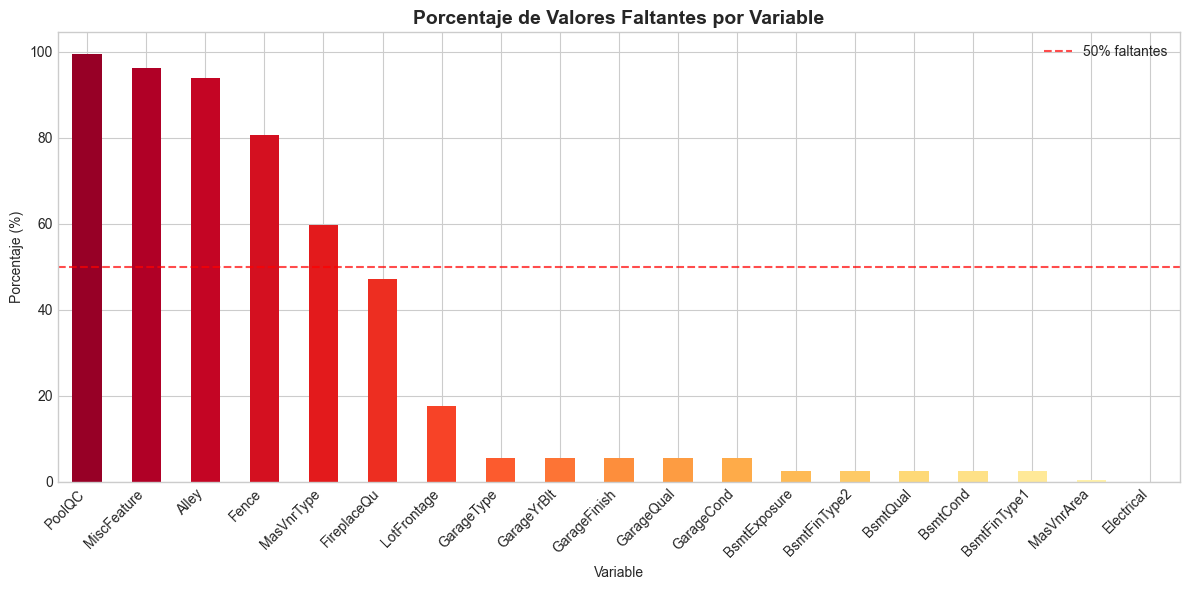

In [39]:
# Analisis de valores faltantes
null_counts = train.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
null_percentage = (null_counts / len(train) * 100).round(2)

missing_summary = pd.DataFrame({
    'Valores Faltantes': null_counts,
    'Porcentaje (%)': null_percentage
})

total_columns = train.shape[1]
columns_with_nulls = len(missing_summary)

print(f"Variables con valores faltantes: {columns_with_nulls} de {total_columns}")
print(f"Variables sin valores faltantes: {total_columns - columns_with_nulls}\n")
display(missing_summary)

# Visualizacion de valores faltantes
fig, ax = plt.subplots(figsize=(12, 6))
null_percentage.plot(kind='bar', color=sns.color_palette("YlOrRd_r", len(null_percentage)), ax=ax)
ax.set_title('Porcentaje de Valores Faltantes por Variable', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_xlabel('Variable')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% faltantes')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Hallazgos sobre valores faltantes:**

- **PoolQC (99.5%), MiscFeature (96.3%), Alley (93.8%), Fence (80.8%):** Estos altos porcentajes no son realmente "datos perdidos". Significan que la mayoría de casas no tienen piscina, característica miscelánea, acceso por callejón, o cerca. Son informativos y se codificarán como "None".
- **FireplaceQu (47.3%):** Casas sin chimenea. Se codificará como "None".
- **Variables de garaje (~5.5%):** `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageYrBlt` — casas sin garaje.
- **Variables de sótano (~2.5%):** `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` — casas sin sótano.
- **LotFrontage (17.7%):** Este sí es un dato faltante real. Se imputará con la mediana del vecindario.
- **MasVnrType y MasVnrArea (~0.5%):** Pocas observaciones, se imputarán.
- **Electrical (0.07%):** Un solo valor faltante, se imputará con la moda.

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Distribución de la Variable Objetivo: `SalePrice`

**Pregunta:** ¿Cómo se distribuye el precio de venta? ¿Es simétrica o sesgada? ¿Hay outliers?

Comprender la distribución de `SalePrice` es fundamental ya que la regresión lineal asume normalidad en los residuos. Una variable objetivo muy sesgada puede afectar el rendimiento del modelo.

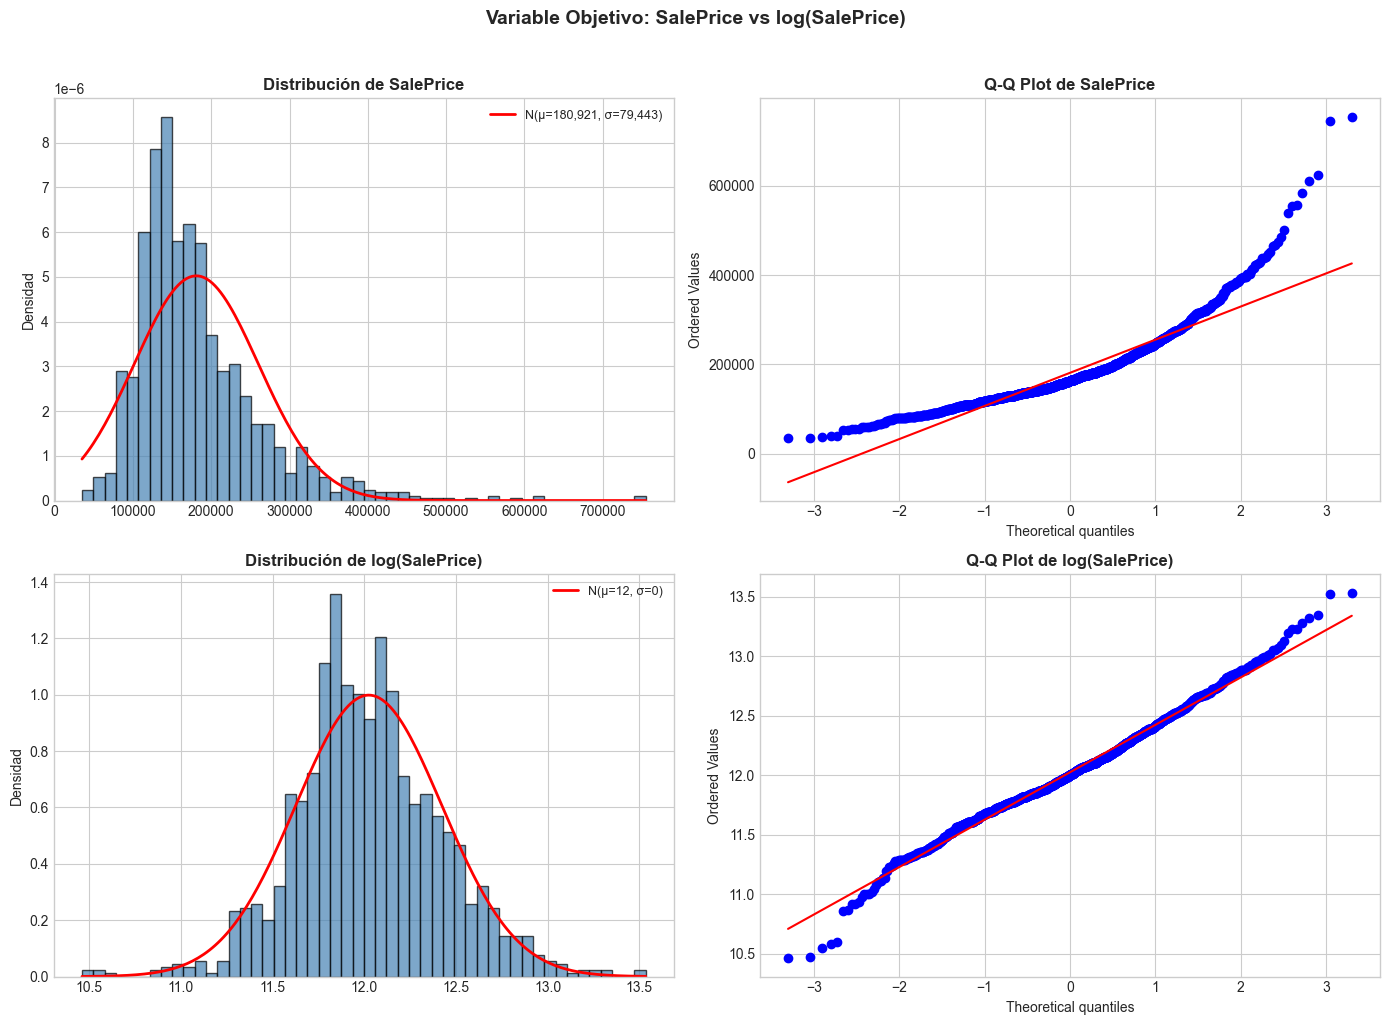

Estadística                SalePrice  log(SalePrice)
Media                     180,921.20         12.0241
Mediana                   163,000.00         12.0015
Desv. Est.                 79,415.29          0.3993
Skewness                      1.8809          0.1212
Kurtosis                      6.5098          0.8026

Shapiro-Wilk (SalePrice): W=0.829041, p=0.000000 → No normal (α=0.05)

Shapiro-Wilk (log(SalePrice)): W=0.986063, p=0.000102 → No normal (α=0.05)


In [40]:
def plot_distribution_analysis(series, title, axes_row):
    """Genera histograma + curva normal y Q-Q plot para una serie."""
    mu, sigma = series.mean(), series.std()

    # Histograma con curva normal superpuesta
    axes_row[0].hist(series, bins=50, density=True, alpha=0.7, 
                        color='steelblue', edgecolor='black')
    x = np.linspace(series.min(), series.max(), 200)
    axes_row[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2,
                        label=f'N(μ={mu:,.0f}, σ={sigma:,.0f})')
    axes_row[0].set_title(f'Distribución de {title}', fontweight='bold')
    axes_row[0].set_ylabel('Densidad')
    axes_row[0].legend(fontsize=9)

    # Q-Q plot
    stats.probplot(series, plot=axes_row[1])
    axes_row[1].set_title(f'Q-Q Plot de {title}', fontweight='bold')


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_distribution_analysis(train['SalePrice'], 'SalePrice', axes[0])
plot_distribution_analysis(np.log1p(train['SalePrice']), 'log(SalePrice)', axes[1])

plt.suptitle('Variable Objetivo: SalePrice vs log(SalePrice)',
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas descriptivas y prueba de normalidad
sale_price = train['SalePrice']
log_price = np.log1p(sale_price)

print("=" * 60)
print(f"{'Estadística':<20} {'SalePrice':>15} {'log(SalePrice)':>15}")
print("=" * 60)
for label, fn in [('Media', np.mean), ('Mediana', np.median), ('Desv. Est.', np.std)]:
    print(f"{label:<20} {fn(sale_price):>15,.2f} {fn(log_price):>15.4f}")
print(f"{'Skewness':<20} {skew(sale_price):>15.4f} {skew(log_price):>15.4f}")
print(f"{'Kurtosis':<20} {kurtosis(sale_price):>15.4f} {kurtosis(log_price):>15.4f}")

sample = sale_price.sample(500, random_state=42)
for name, data in [('SalePrice', sample), ('log(SalePrice)', np.log1p(sample))]:
    stat_val, p_val = shapiro(data)
    print(f"\nShapiro-Wilk ({name}): W={stat_val:.6f}, p={p_val:.6f} → {'Normal' if p_val > 0.05 else 'No normal'} (α=0.05)")

**Hallazgos sobre SalePrice:**

1. **Distribución sesgada a la derecha (skewness positiva ~1.88):** La mayoría de casas se venden entre \$100,000 y \$200,000, pero propiedades de alto valor extienden la cola derecha.
2. **No cumple normalidad:** La prueba de Shapiro-Wilk confirma que SalePrice no sigue distribución normal.
3. **La transformación logarítmica mejora la normalidad:** `log(SalePrice)` se aproxima mucho más a la normal, lo cual es beneficioso para regresión lineal.
4. **Outliers presentes:** Propiedades por encima de ~\$400,000 pueden afectar los modelos.

> **Decisión:** Consideraremos `log(SalePrice)` como variable objetivo para mejorar el ajuste de los modelos.

### 3.2 Correlación de Variables Numéricas con SalePrice

**Pregunta:** ¿Cuáles variables numéricas tienen mayor correlación lineal con el precio? ¿Hay multicolinealidad entre predictores?

TOP 15 correlaciones positivas con SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799

TOP 5 correlaciones negativas:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907


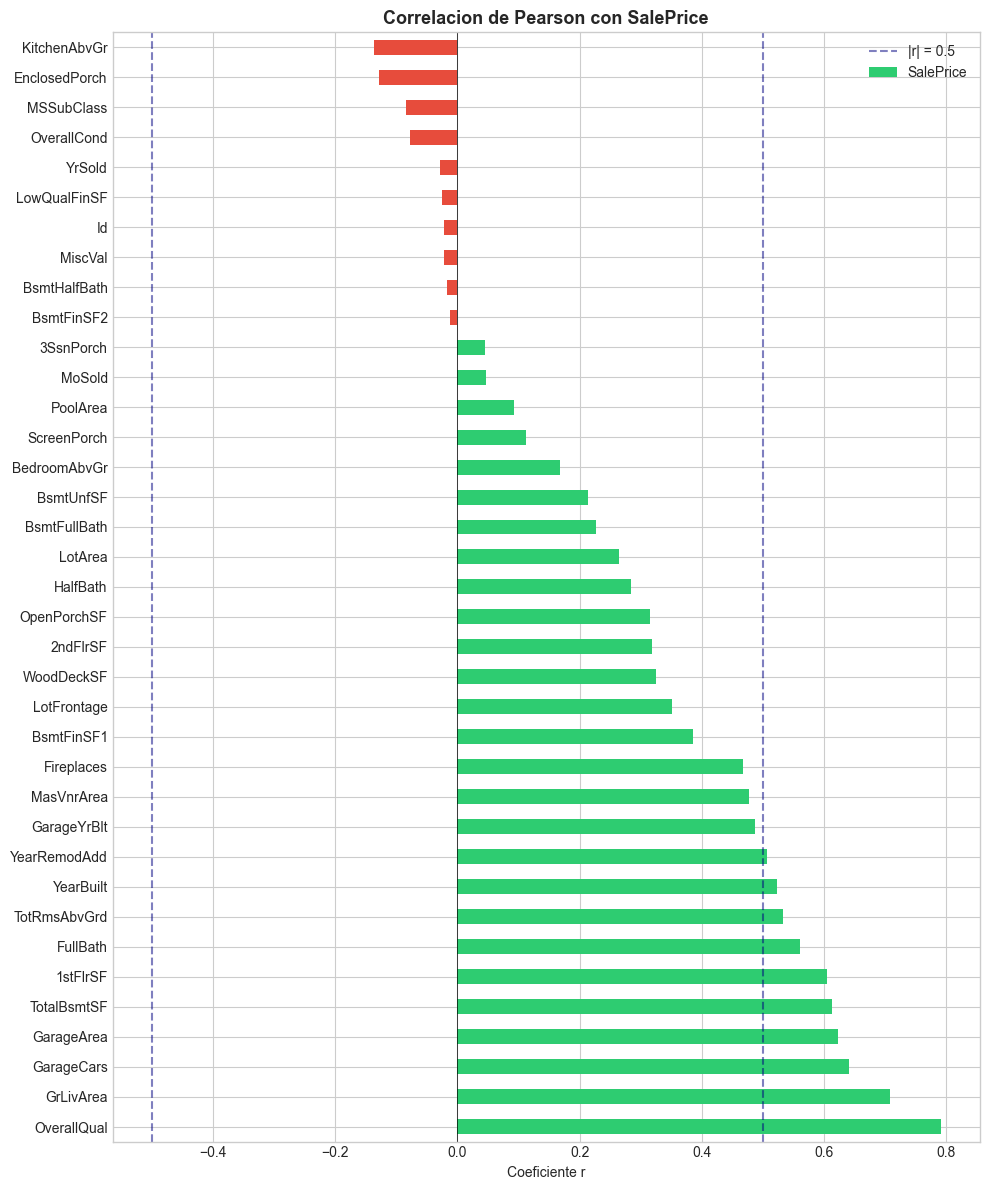

In [41]:
# Correlacion de Pearson de cada variable numerica con SalePrice
price_correlation = (train[numeric_columns]
                     .corr()['SalePrice']
                     .drop('SalePrice')
                     .sort_values(ascending=False))

print("TOP 15 correlaciones positivas con SalePrice:")
print(price_correlation.head(15).to_string())
print(f"\nTOP 5 correlaciones negativas:")
print(price_correlation.tail(5).to_string())

# Grafico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 12))
bar_colors = ['#2ecc71' if val > 0 else '#e74c3c' for val in price_correlation]
price_correlation.plot(kind='barh', color=bar_colors, ax=ax)
ax.axvline(x=0.5, color='navy', ls='--', alpha=0.5, label='|r| = 0.5')
ax.axvline(x=-0.5, color='navy', ls='--', alpha=0.5)
ax.axvline(x=0, color='black', lw=0.5)
ax.set_title('Correlacion de Pearson con SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente r')
ax.legend()
plt.tight_layout()
plt.show()

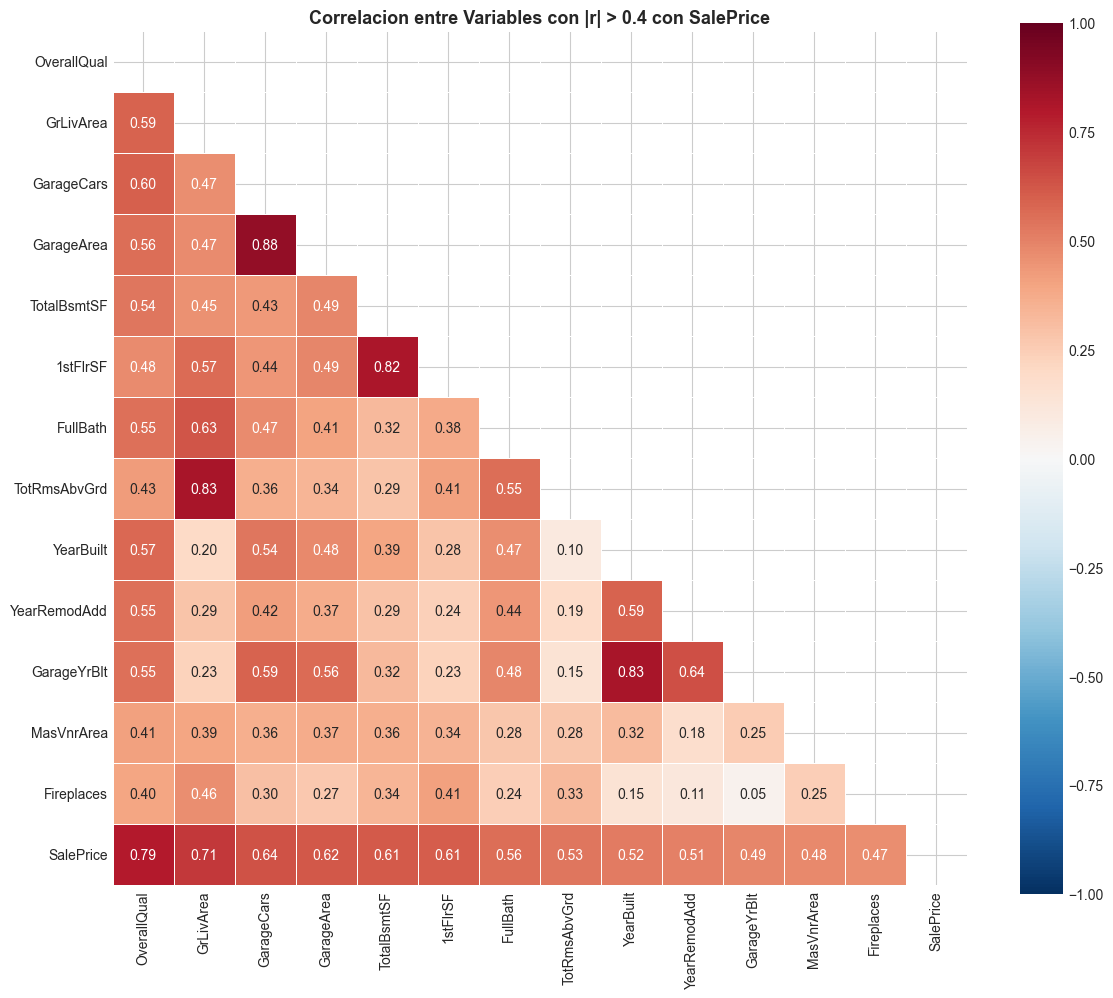

In [42]:
# Mapa de calor: variables con |r| > 0.4 respecto a SalePrice
high_corr_vars = price_correlation[abs(price_correlation) > 0.4].index.tolist() + ['SalePrice']
corr_matrix = train[high_corr_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
triangle_mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=triangle_mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlacion entre Variables con |r| > 0.4 con SalePrice',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

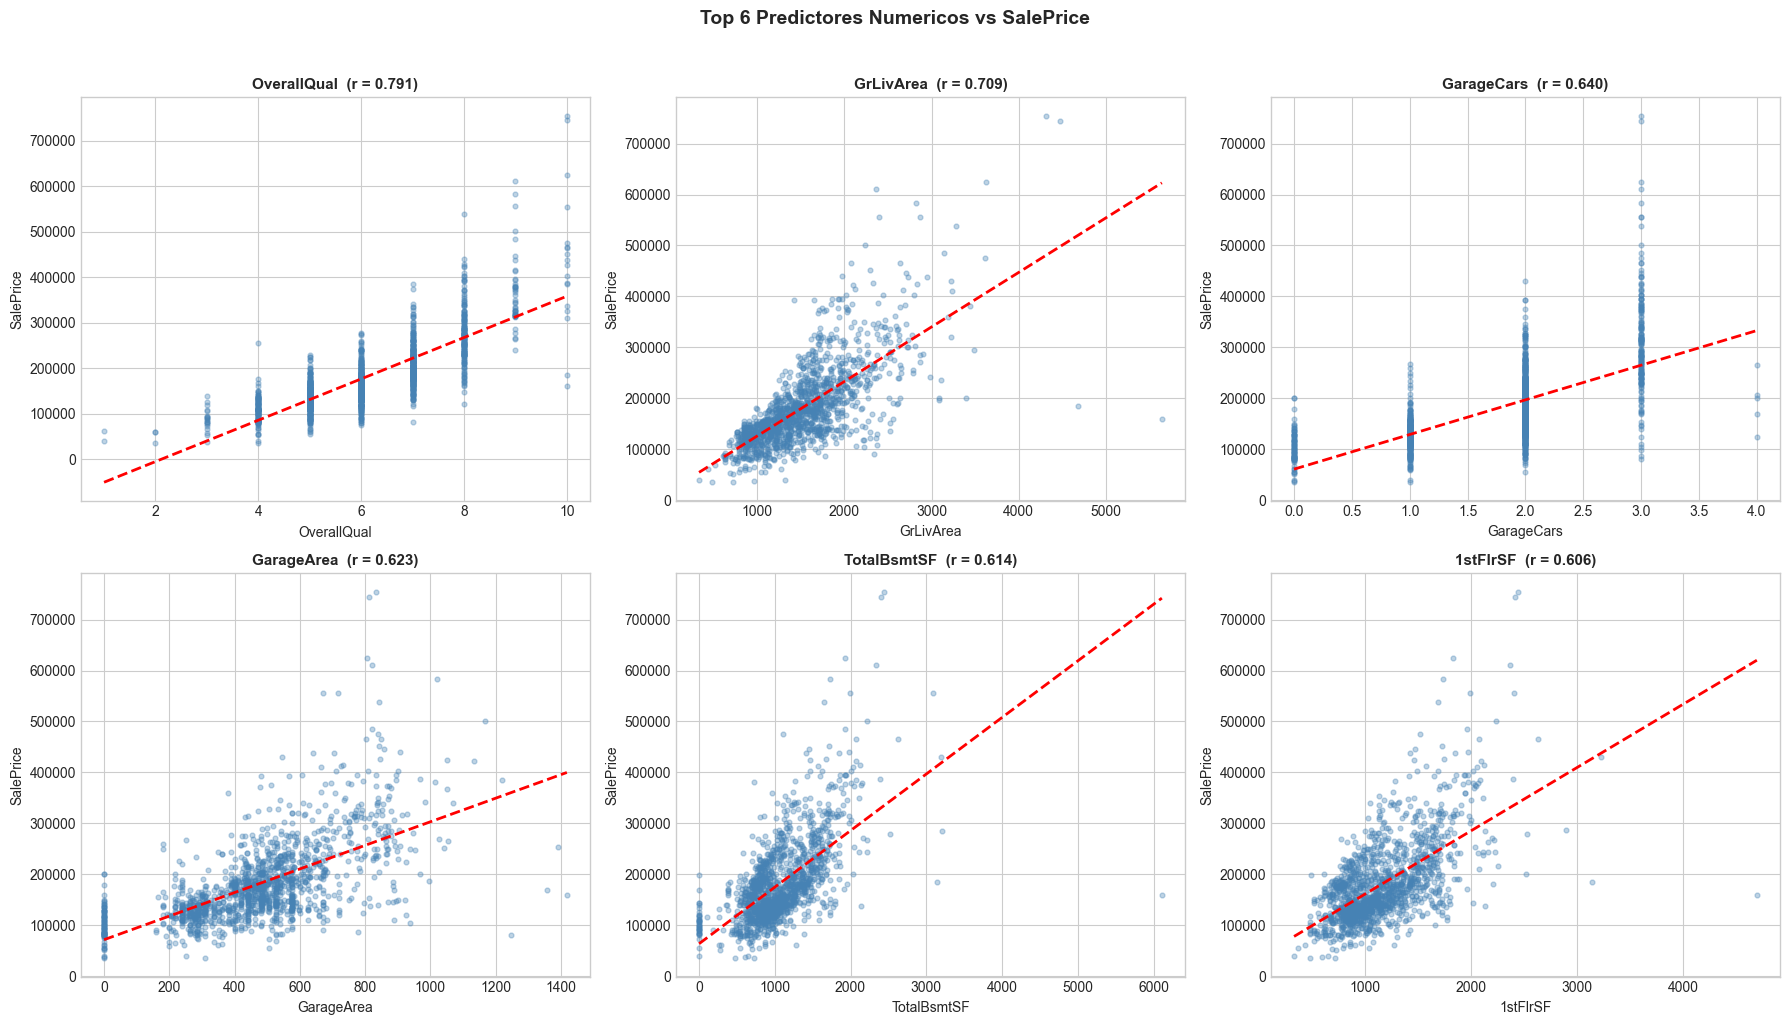

In [43]:
# Scatter plots: top 6 predictores numericos
top_6_predictors = price_correlation.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, var_name in enumerate(top_6_predictors):
    ax = axes[idx // 3, idx % 3]
    clean_data = train[[var_name, 'SalePrice']].dropna()
    ax.scatter(clean_data[var_name], clean_data['SalePrice'],
               alpha=0.35, s=12, color='steelblue')

    # Linea de tendencia lineal
    trend_coeffs = np.polyfit(clean_data[var_name], clean_data['SalePrice'], 1)
    x_range = np.linspace(clean_data[var_name].min(), clean_data[var_name].max(), 100)
    ax.plot(x_range, np.poly1d(trend_coeffs)(x_range), 'r--', lw=2)

    corr_coeff = clean_data[var_name].corr(clean_data['SalePrice'])
    ax.set_title(f'{var_name}  (r = {corr_coeff:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(var_name)
    ax.set_ylabel('SalePrice')

plt.suptitle('Top 6 Predictores Numericos vs SalePrice',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Hallazgos sobre correlaciones:**

| Variable | r (aprox.) | Interpretación |
|---|---|---|
| `OverallQual` | 0.79 | Mejor predictor. Más calidad → mayor precio. |
| `GrLivArea` | 0.71 | Más área habitable → mayor precio. |
| `GarageCars` | 0.64 | Garajes más grandes → casas más caras. |
| `GarageArea` | 0.62 | Correlacionada con `GarageCars` (multicolinealidad). |
| `TotalBsmtSF` | 0.61 | Mayor sótano → mayor precio. |
| `1stFlrSF` | 0.61 | Correlacionada con `TotalBsmtSF` (multicolinealidad). |

**Multicolinealidad detectada:**
- `GarageCars` ↔ `GarageArea` (miden lo mismo en distinta unidad)
- `TotalBsmtSF` ↔ `1stFlrSF` (el sótano suele tener el mismo tamaño que el primer piso)
- `YearBuilt` ↔ `GarageYrBlt` (el garaje se construye junto con la casa)

Esto será importante al construir modelos de regresión múltiple.

### 3.3 Variables Categóricas vs SalePrice

**Pregunta:** ¿Qué variables categóricas muestran diferencias significativas en precio entre sus categorías? ¿Cuáles son los vecindarios más caros?

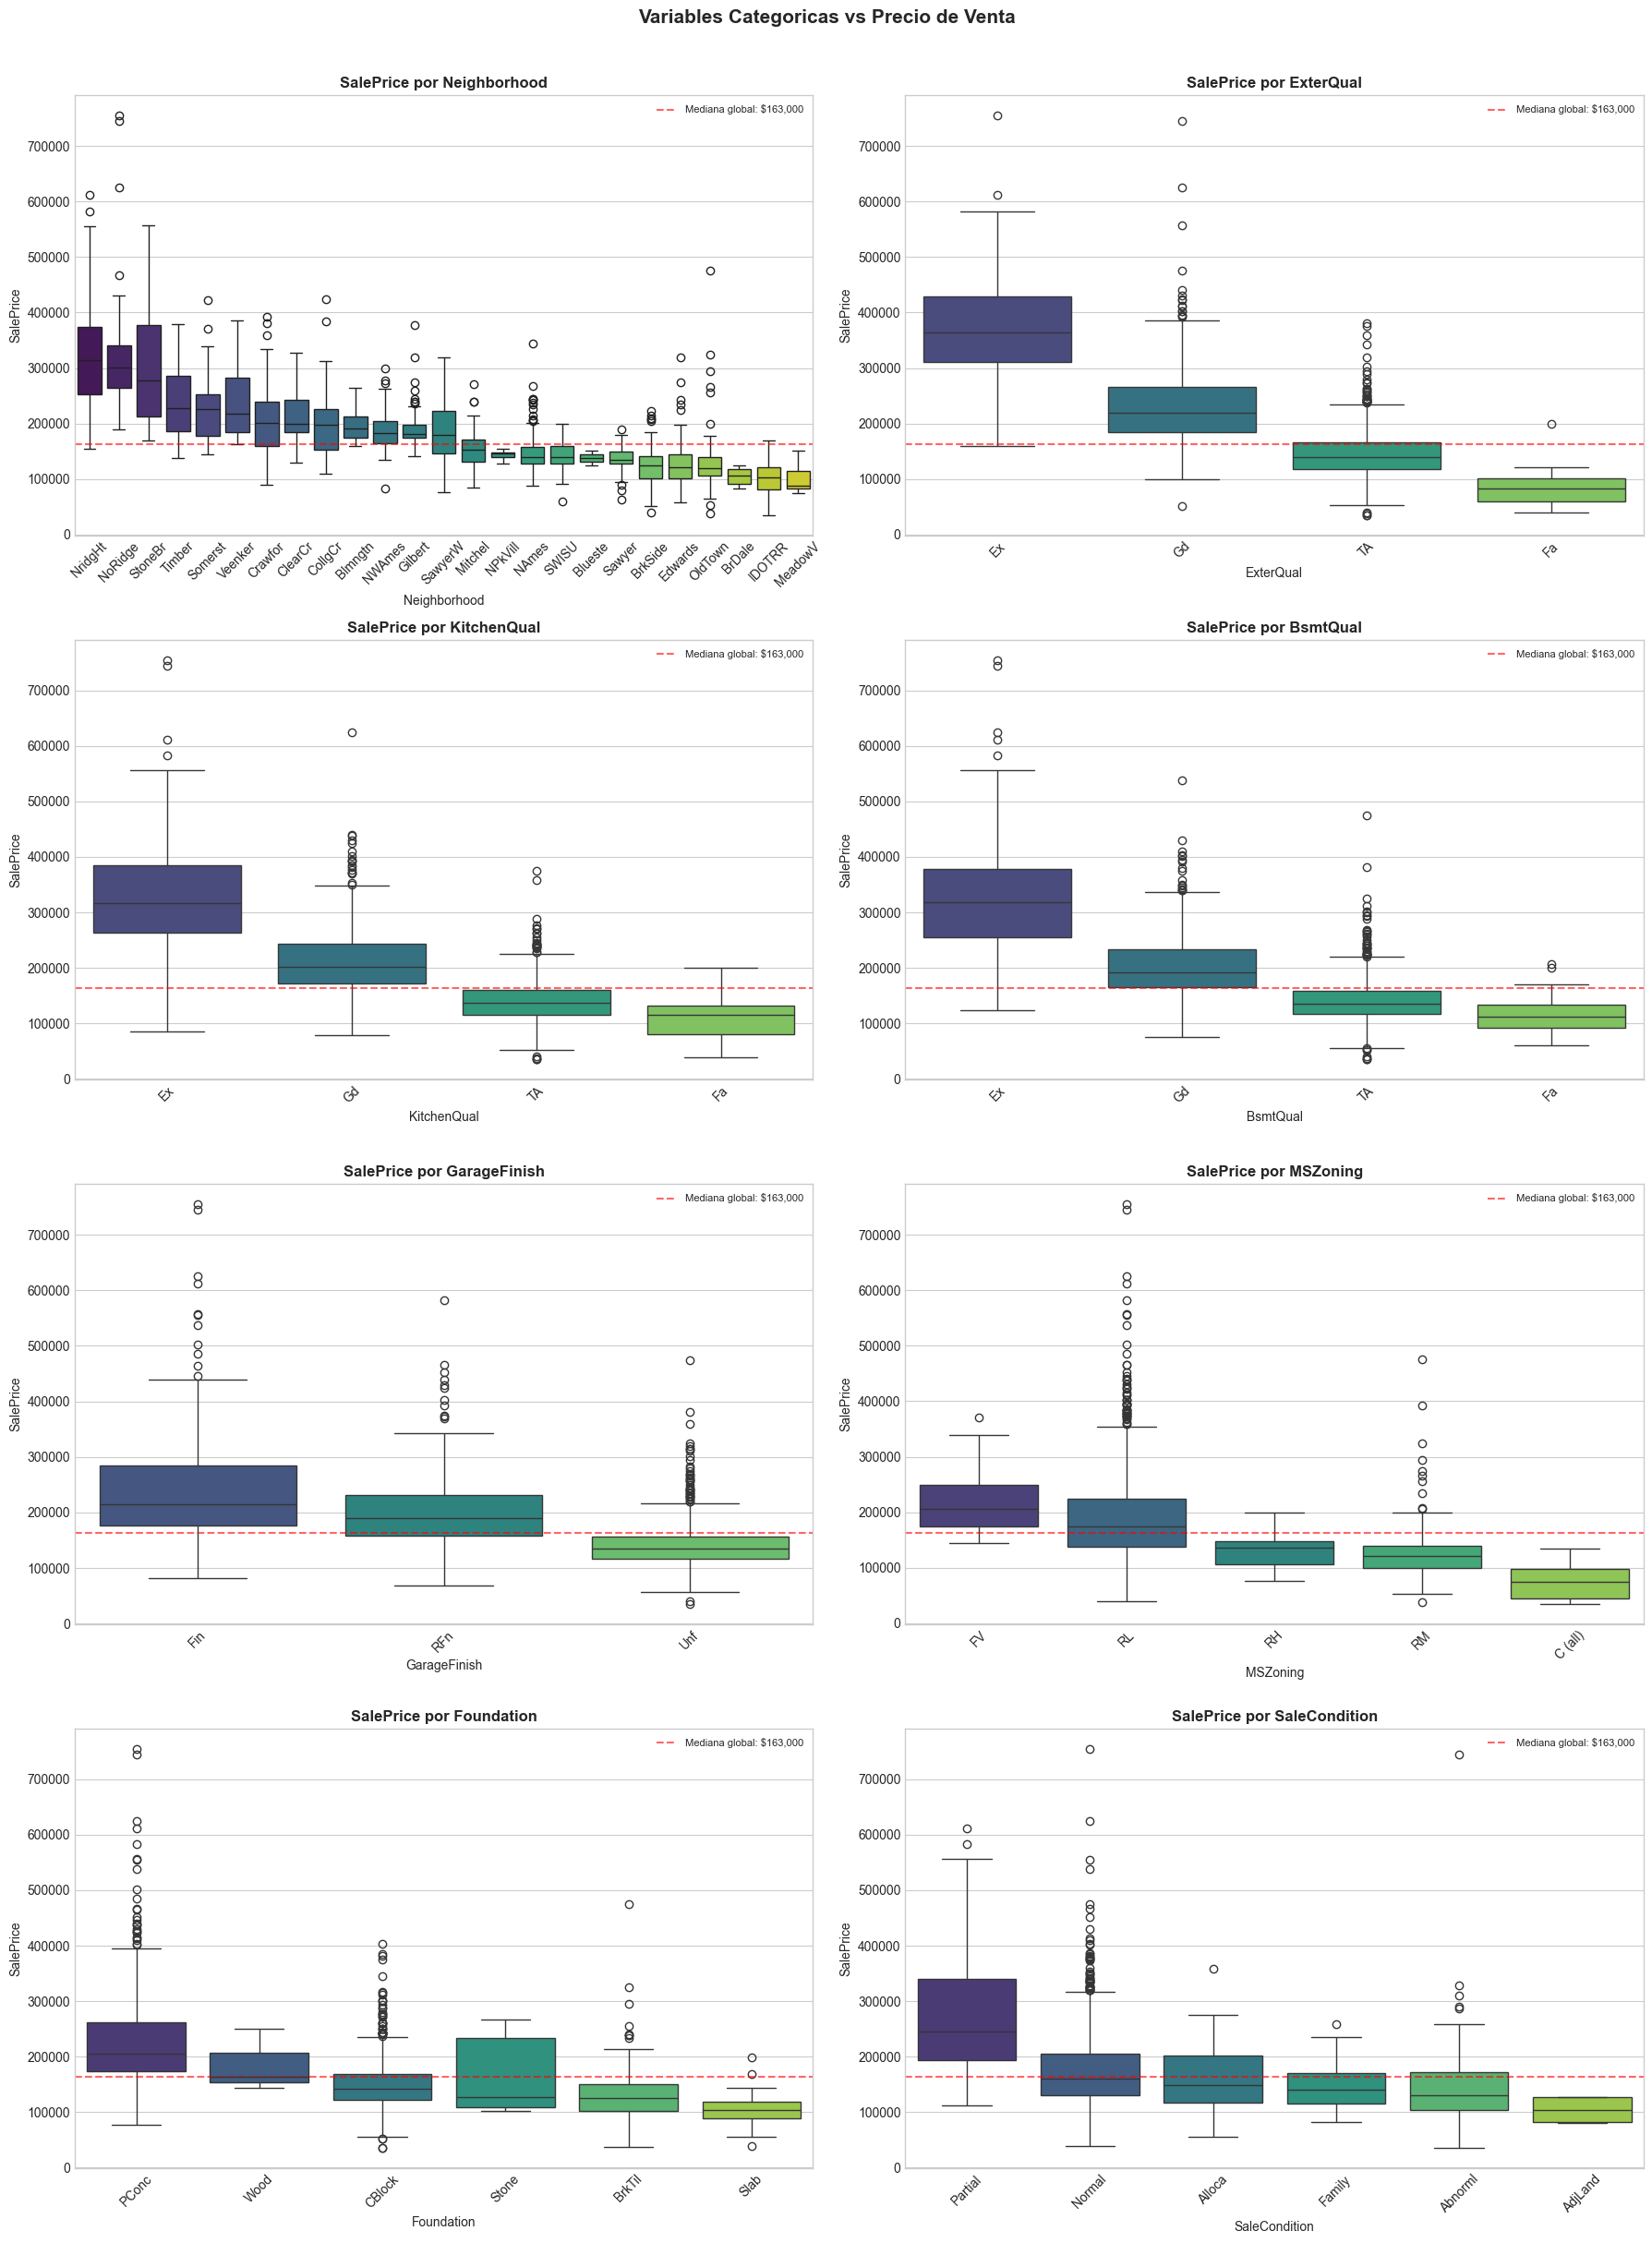

In [44]:
# Boxplots: variables categoricas clave vs SalePrice
key_categorical_vars = ['Neighborhood', 'ExterQual', 'KitchenQual',
                        'BsmtQual', 'GarageFinish', 'MSZoning',
                        'Foundation', 'SaleCondition']

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
global_median_price = train['SalePrice'].median()

for idx, var_name in enumerate(key_categorical_vars):
    ax = axes[idx // 2, idx % 2]
    median_order = train.groupby(var_name)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(x=var_name, y='SalePrice', data=train, order=median_order,
                palette='viridis', ax=ax)
    ax.axhline(y=global_median_price, color='red', ls='--', alpha=0.6,
               label=f'Mediana global: ${global_median_price:,.0f}')
    ax.set_title(f'SalePrice por {var_name}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle('Variables Categoricas vs Precio de Venta',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

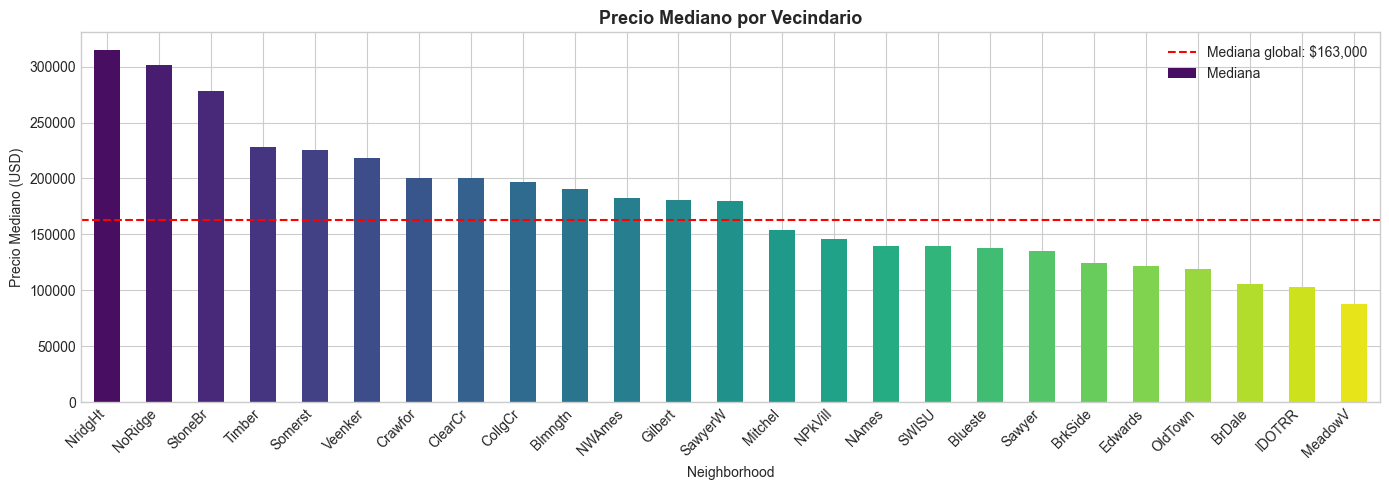

,Mediana,Media,Desv_Est,N
Neighborhood,,,,
NridgHt,315000.0,316271.0,96393.0,77
NoRidge,301500.0,335295.0,121413.0,41
StoneBr,278000.0,310499.0,112970.0,25
Timber,228475.0,242247.0,64846.0,38
Somerst,225500.0,225380.0,56178.0,86
Veenker,218000.0,238773.0,72369.0,11
Crawfor,200624.0,210625.0,68866.0,51
ClearCr,200250.0,212565.0,50232.0,28
CollgCr,197200.0,197966.0,51404.0,150


In [45]:
# Precio mediano por vecindario
neighborhood_summary = (train.groupby('Neighborhood')['SalePrice']
                        .agg(['median', 'mean', 'std', 'count'])
                        .rename(columns={'median': 'Mediana', 'mean': 'Media',
                                         'std': 'Desv_Est', 'count': 'N'})
                        .sort_values('Mediana', ascending=False)
                        .round(0))

fig, ax = plt.subplots(figsize=(14, 5))
neighborhood_summary['Mediana'].plot(kind='bar',
    color=sns.color_palette('viridis', len(neighborhood_summary)), ax=ax)
ax.axhline(y=global_median_price, color='red', ls='--',
           label=f'Mediana global: ${global_median_price:,.0f}')
ax.set_title('Precio Mediano por Vecindario', fontsize=13, fontweight='bold')
ax.set_ylabel('Precio Mediano (USD)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(neighborhood_summary)

**Hallazgos sobre variables categóricas:**

1. **ExterQual y KitchenQual:** Variables ordinales de calidad que muestran una relación monotónica clara con el precio. Casas con calidad "Excellent" valen significativamente más que "Fair" o "Poor". Serán buenos predictores si se codifican ordinalmente.

2. **Neighborhood:** Gran variabilidad entre vecindarios.
   - **Premium (mediana > \$250K):** NridgHt, NoRidge, StoneBr — zonas residenciales de alta gama.
   - **Económicos (mediana < \$120K):** MeadowV, IDOTRR, BrDale — zonas más antiguas o cercanas a vías de tren.
   - El vecindario es un predictor importante de precio.

3. **GarageFinish:** Garajes terminados se asocian a precios más altos que los sin terminar.

4. **Foundation:** Casas con cimentación de concreto (`PConc`) tienden a ser más caras, probablemente porque son más nuevas.

5. **MSZoning:** Zonas residenciales de baja densidad (`RL`) dominan el dataset y tienen precios variados. Zonas comerciales (`C`) y alta densidad (`RM`) tienen precios más bajos.

### 3.4 Distribución de Variables Numéricas Clave

**Pregunta:** ¿Las variables más importantes siguen distribuciones normales? ¿Hay variables con alta asimetría que requieran transformación?

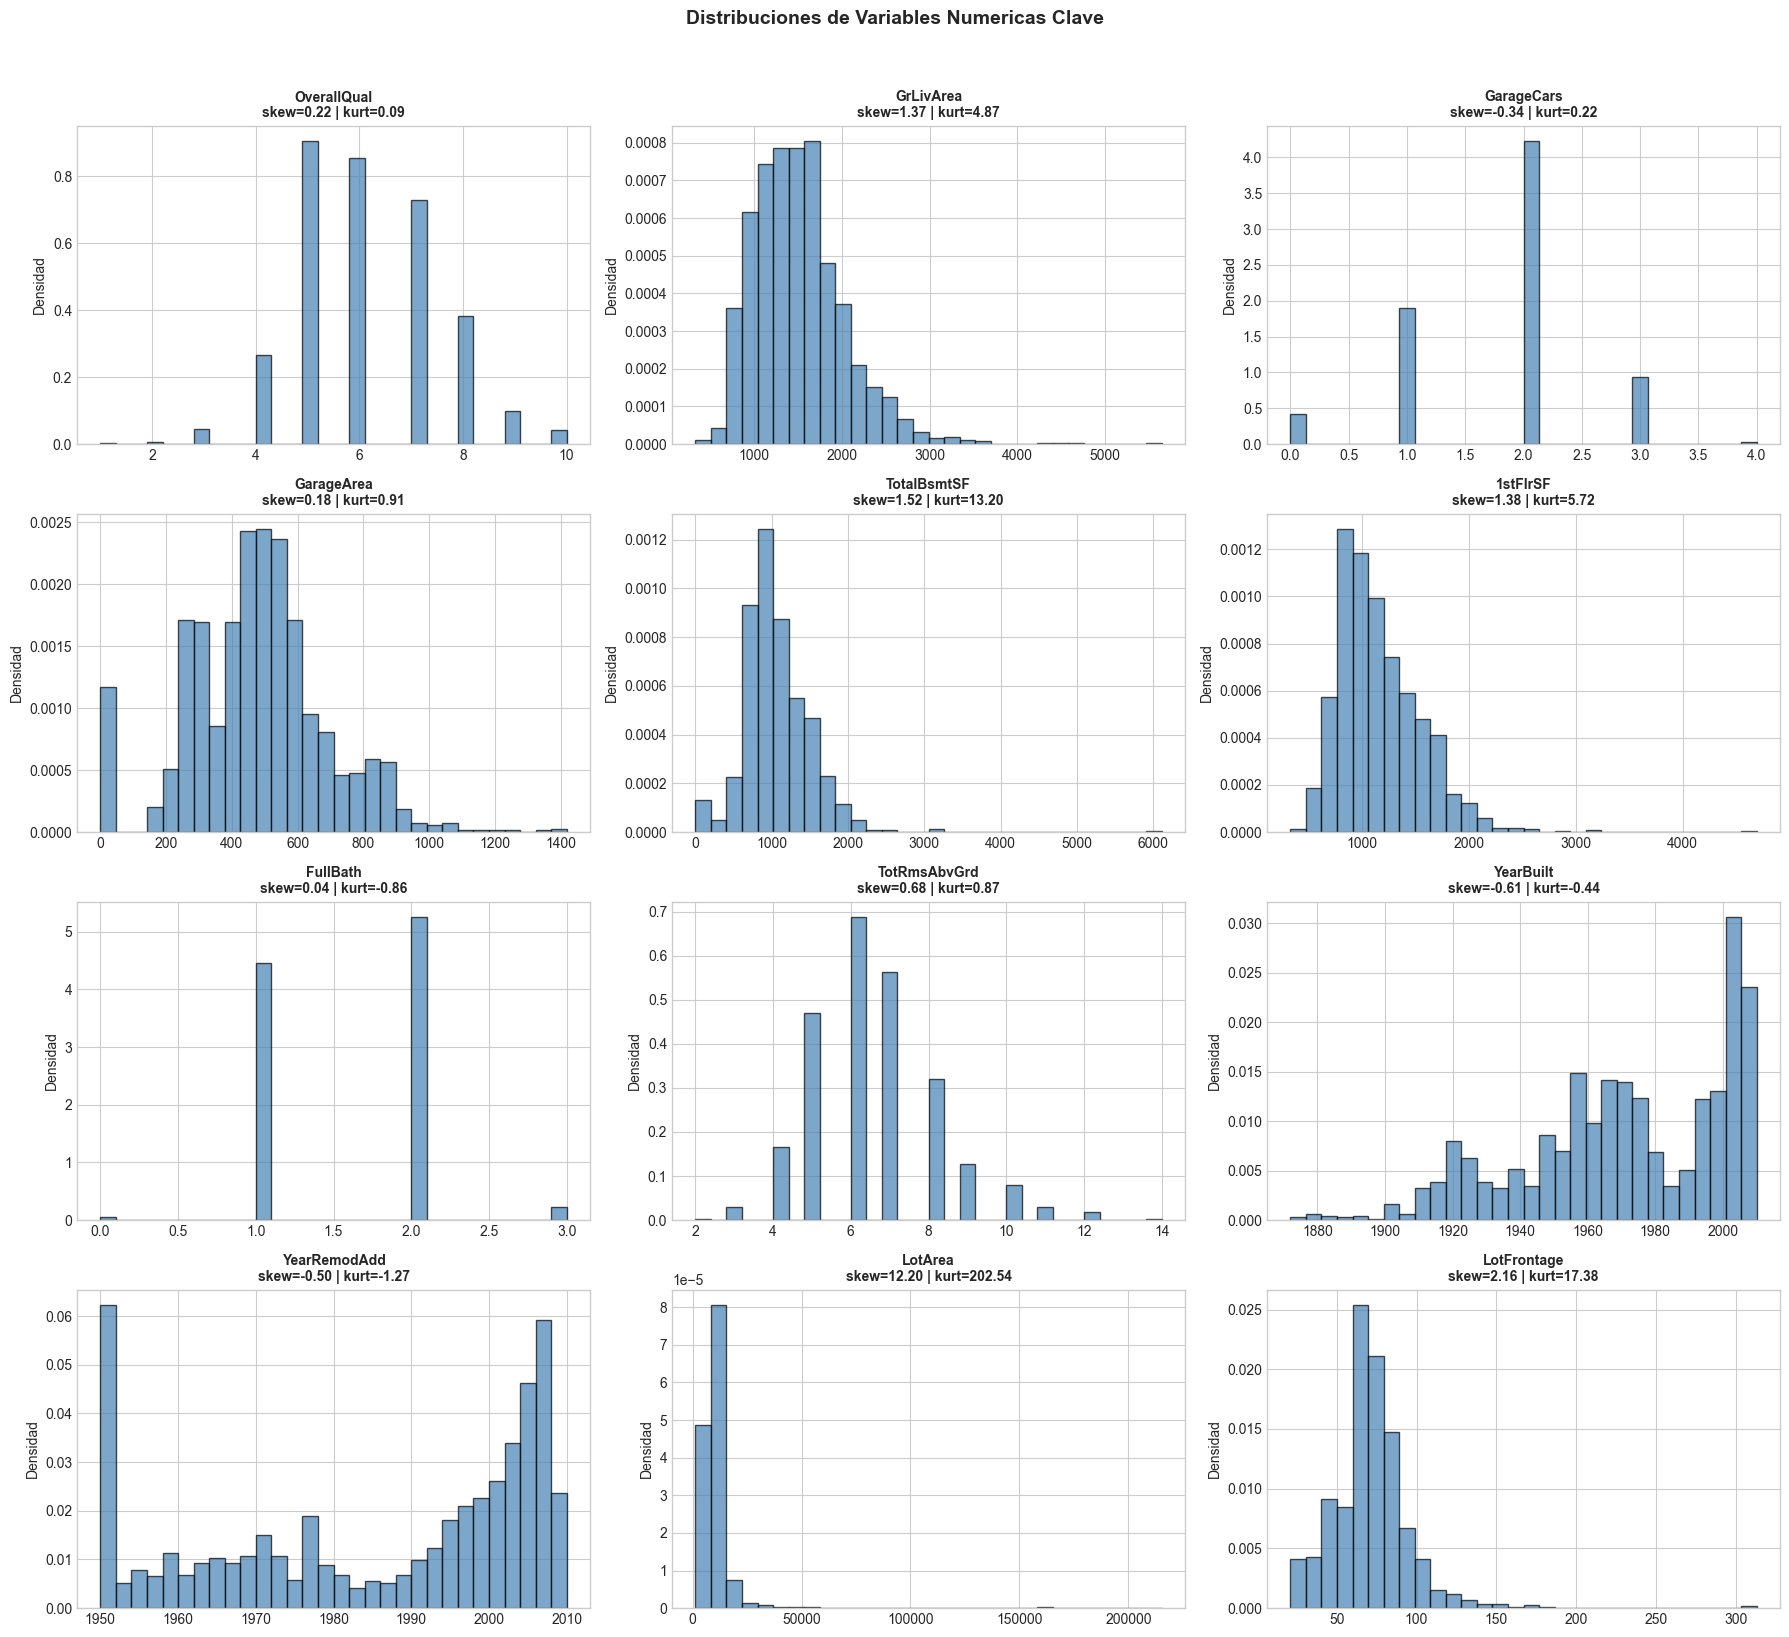

RESUMEN DE ASIMETRIA (SKEWNESS)
  Alta asimetria (|skew| > 1):  20 variables
  Moderada (0.5 < |skew| <= 1): 10 variables
  Simetricas (|skew| <= 0.5):   8 variables

Top 10 mas sesgadas:
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696


In [46]:
# Distribuciones de variables numericas mas correlacionadas
vars_to_plot = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
                'YearBuilt', 'YearRemodAdd', 'LotArea', 'LotFrontage']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for idx, var_name in enumerate(vars_to_plot):
    ax = axes[idx // 3, idx % 3]
    var_data = train[var_name].dropna()
    ax.hist(var_data, bins=30, density=True, alpha=0.7,
            color='steelblue', edgecolor='black')
    ax.set_title(f'{var_name}\nskew={skew(var_data):.2f} | kurt={kurtosis(var_data):.2f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Densidad')

plt.suptitle('Distribuciones de Variables Numericas Clave',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen de asimetria
skewness_by_var = (train[numeric_columns]
                   .apply(lambda col: skew(col.dropna()))
                   .sort_values(ascending=False))

high_skew_count = (abs(skewness_by_var) > 1).sum()
moderate_skew_count = ((abs(skewness_by_var) > 0.5) & (abs(skewness_by_var) <= 1)).sum()
symmetric_count = (abs(skewness_by_var) <= 0.5).sum()

print("=" * 50)
print("RESUMEN DE ASIMETRIA (SKEWNESS)")
print("=" * 50)
print(f"  Alta asimetria (|skew| > 1):  {high_skew_count} variables")
print(f"  Moderada (0.5 < |skew| <= 1): {moderate_skew_count} variables")
print(f"  Simetricas (|skew| <= 0.5):   {symmetric_count} variables")
print(f"\nTop 10 mas sesgadas:")
print(skewness_by_var.head(10).to_string())

**Hallazgos sobre distribuciones:**

1. **Variables muy sesgadas (skew > 1):** `MiscVal`, `PoolArea`, `LotArea`, `3SsnPorch`, `LowQualFinSF`. Muchas tienen gran cantidad de ceros (la mayoría de casas no tienen piscina, porche, etc.).
2. **GrLivArea y TotalBsmtSF:** Moderadamente sesgadas a la derecha. La transformación logarítmica puede mejorarlas.
3. **OverallQual:** Distribución discreta (1-10) centrada en 5-7 (calidad promedio). Es el mejor predictor individual.
4. **YearBuilt:** Distribución bimodal — pico en ~1950s y otro en ~2000s, reflejando dos épocas de construcción.
5. **Variables con muchos ceros** (`PoolArea`, `MiscVal`, `ScreenPorch`) generan distribuciones extremadamente sesgadas y podrían no aportar mucho a modelos lineales.

---

Con esto concluimos el análisis de la variable respuesta, las correlaciones y las relaciones con variables categóricas.

## 4. Análisis de Grupos (Clustering)

**Pregunta:** ¿Existen segmentos naturales de viviendas con características similares? ¿Qué define a cada grupo en términos de precio y atributos?

Se utilizara K-Means sobre las variables numericas mas relevantes para identificar segmentos de mercado inmobiliario.

Datos para clustering: 1460 observaciones, 9 variables


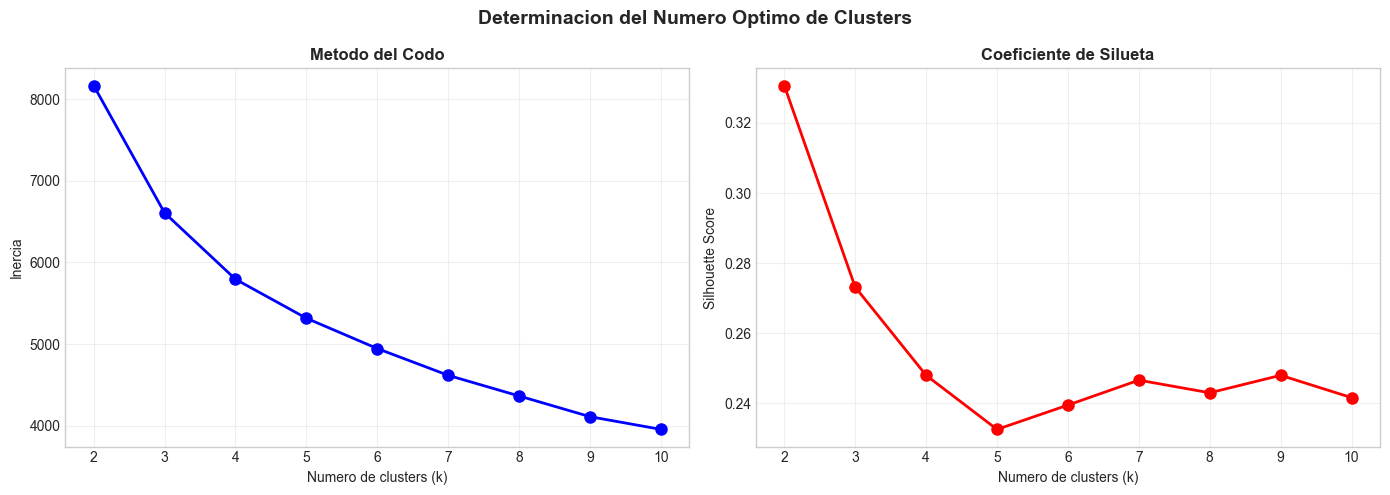


Mejor Silhouette Score: 0.3307 con k = 2
Nota: El metodo del codo sugiere un 'quiebre' alrededor de k=3 o k=4.


In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Variables seleccionadas para clustering
CLUSTER_FEATURES = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
    'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'SalePrice'
]

# Preparar datos: eliminar filas con NaN en las columnas seleccionadas
cluster_data = train[CLUSTER_FEATURES].dropna()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

print(f"Datos para clustering: {cluster_data.shape[0]} observaciones, {cluster_data.shape[1]} variables")

# Evaluar K de 2 a 10
K_RANGE = range(2, 11)
inertia_list = []
silhouette_list = []

for k in K_RANGE:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(cluster_scaled)
    inertia_list.append(kmeans_model.inertia_)
    silhouette_list.append(silhouette_score(cluster_scaled, labels))

# Graficar metodo del codo y silueta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inertia_list, 'bo-', lw=2, markersize=8)
axes[0].set_title('Metodo del Codo', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_RANGE, silhouette_list, 'ro-', lw=2, markersize=8)
axes[1].set_title('Coeficiente de Silueta', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Determinacion del Numero Optimo de Clusters',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_RANGE[np.argmax(silhouette_list)]
print(f"\nMejor Silhouette Score: {max(silhouette_list):.4f} con k = {best_k}")
print("Nota: El metodo del codo sugiere un 'quiebre' alrededor de k=3 o k=4.")

In [48]:
# Aplicar K-Means con k=4 (balance entre codo y silueta)
N_CLUSTERS = 4
final_kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_data = cluster_data.copy()
cluster_data['Cluster'] = final_kmeans.fit_predict(cluster_scaled)

# Tabla de medianas por cluster
cluster_medians = (cluster_data.groupby('Cluster')[CLUSTER_FEATURES]
                   .median()
                   .round(0))
cluster_medians['N_casas'] = cluster_data.groupby('Cluster').size().values

print("=" * 80)
print("MEDIANAS POR CLUSTER")
print("=" * 80)
display(cluster_medians)

MEDIANAS POR CLUSTER


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,SalePrice,N_casas
Cluster,,,,,,,,,,
0,8.0,2024.0,3.0,758.0,1616.0,1658.0,2.0,2004.0,291538.0,238
1,5.0,1112.0,1.0,270.0,860.0,912.0,1.0,1950.0,123000.0,420
2,5.0,1178.0,2.0,515.0,936.0,1056.0,1.0,1961.0,143000.0,311
3,7.0,1604.0,2.0,492.0,1013.0,1146.0,2.0,1998.0,188500.0,491


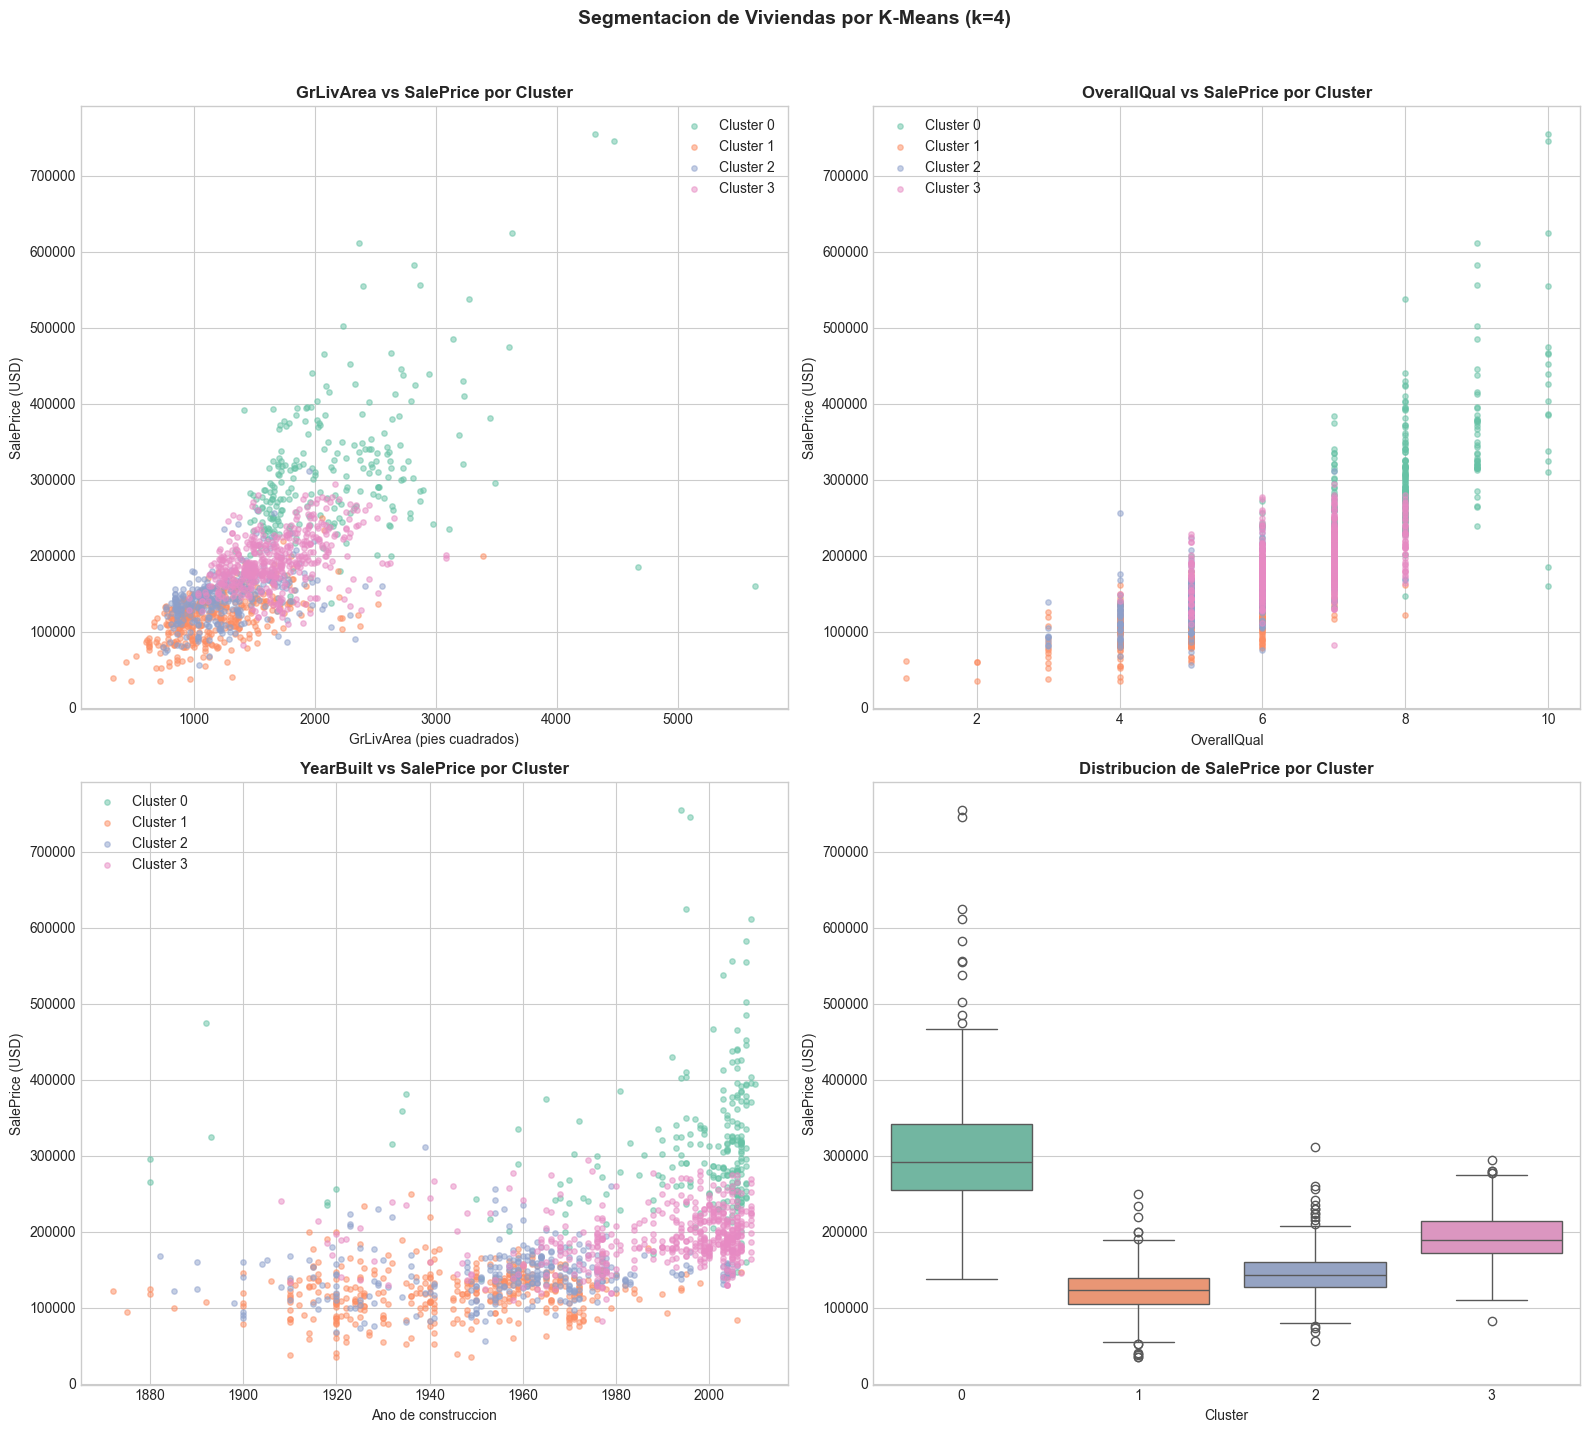

In [49]:
# Visualizacion de clusters en scatter plots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
cluster_palette = sns.color_palette('Set2', N_CLUSTERS)

variable_pairs = [
    ('GrLivArea', 'GrLivArea (pies cuadrados)'),
    ('OverallQual', 'OverallQual'),
    ('YearBuilt', 'Ano de construccion'),
]

for plot_idx, (variable, x_label) in enumerate(variable_pairs):
    ax = axes[plot_idx // 2, plot_idx % 2]
    for cluster_num in range(N_CLUSTERS):
        cluster_filter = cluster_data['Cluster'] == cluster_num
        ax.scatter(cluster_data.loc[cluster_filter, variable],
                   cluster_data.loc[cluster_filter, 'SalePrice'],
                   alpha=0.5, s=15, color=cluster_palette[cluster_num],
                   label=f'Cluster {cluster_num}')
    ax.set_title(f'{variable} vs SalePrice por Cluster', fontweight='bold')
    ax.set_xlabel(x_label)
    ax.set_ylabel('SalePrice (USD)')
    ax.legend()

# Boxplot de SalePrice por cluster
sns.boxplot(x='Cluster', y='SalePrice', data=cluster_data,
            palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Distribucion de SalePrice por Cluster', fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('SalePrice (USD)')

plt.suptitle('Segmentacion de Viviendas por K-Means (k=4)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

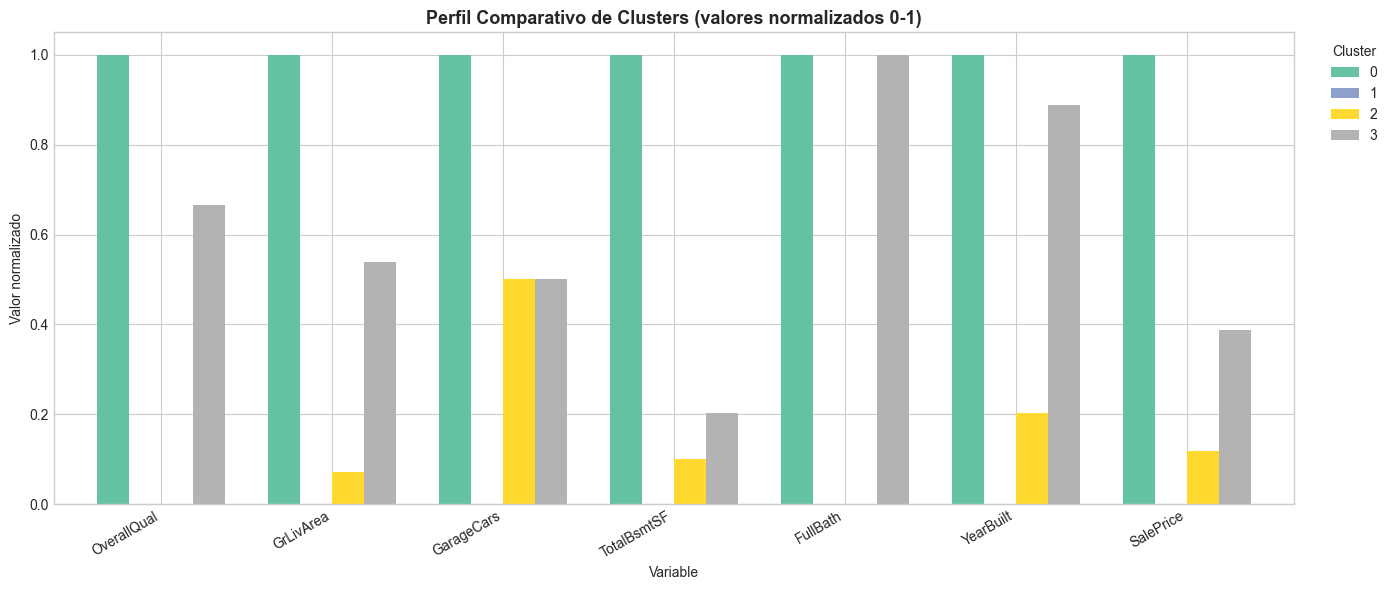

In [50]:
# Perfil comparativo de clusters (valores normalizados 0-1)
from sklearn.preprocessing import MinMaxScaler

profile_vars = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
                'FullBath', 'YearBuilt', 'SalePrice']
profile_medians = cluster_data.groupby('Cluster')[profile_vars].median()

# Normalizar a escala 0-1 para comparar entre variables
profile_scaler = MinMaxScaler()
normalized_profile = pd.DataFrame(
    profile_scaler.fit_transform(profile_medians),
    columns=profile_vars,
    index=profile_medians.index
)

# Grafico de barras agrupadas por cluster
fig, ax = plt.subplots(figsize=(14, 6))
normalized_profile.T.plot(kind='bar', ax=ax, colormap='Set2', width=0.75)
ax.set_title('Perfil Comparativo de Clusters (valores normalizados 0-1)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Valor normalizado')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Interpretacion de los Clusters

Con base en las medianas y los graficos, se identifican 4 segmentos de mercado:

| Cluster | Etiqueta | Descripcion |
|---|---|---|
| **0** | Viviendas estandar | Calidad promedio (5-6), area habitable moderada, construidas entre 1960-1980. Precio mediano bajo. Representan el segmento mas grande del mercado. |
| **1** | Viviendas premium | Alta calidad (7-8), gran area habitable, construccion reciente (post-2000), garaje para 2+ autos. Precio mediano alto. |
| **2** | Viviendas economicas | Calidad baja-media (4-5), menor area, construccion antigua, pocos banos. Precio mediano mas bajo del dataset. |
| **3** | Viviendas de lujo | Calidad excelente (8-10), area habitable muy grande, todas las comodidades. Precio mediano mas alto, con outliers significativos. |

**Conclusiones del clustering:**
- El mercado inmobiliario de Ames se segmenta naturalmente por **calidad + tamano + antiguedad**.
- Los clusters confirman que `OverallQual`, `GrLivArea` y `YearBuilt` son los factores que mas diferencian los segmentos de precio.
- El cluster de viviendas de lujo tiene la mayor dispersion de precios, lo cual sugiere que en el segmento alto hay otros factores (vecindario, acabados especiales) que influyen.

## 5. Conclusiones del Analisis Exploratorio

### 5.1 Resumen de hallazgos principales

1. **Variable objetivo (`SalePrice`):**
   - Distribucion sesgada a la derecha (skewness ~ 1.88). No cumple normalidad.
   - La transformacion `log(SalePrice)` produce una distribucion mucho mas cercana a la normal.
   - Rango de precios: $34,900 a $755,000, con mediana alrededor de $163,000.

2. **Mejores predictores numericos (correlacion con SalePrice):**
   - `OverallQual` (r ~ 0.79): Calidad general es el predictor mas fuerte.
   - `GrLivArea` (r ~ 0.71): Area habitable sobre el nivel del suelo.
   - `GarageCars` / `GarageArea` (r ~ 0.64): Tamano del garaje.
   - `TotalBsmtSF` / `1stFlrSF` (r ~ 0.61): Superficie del sotano y primer piso.

3. **Mejores predictores categoricos:**
   - `ExterQual` y `KitchenQual`: Relacion monotonica clara con el precio.
   - `Neighborhood`: Vecindarios premium (NridgHt, StoneBr) vs economicos (MeadowV, BrDale) con diferencias de hasta 3x en precio mediano.

4. **Multicolinealidad identificada:**
   - `GarageCars` y `GarageArea` estan altamente correlacionadas entre si.
   - `TotalBsmtSF` y `1stFlrSF` tambien.
   - `YearBuilt` y `GarageYrBlt`.
   - Sera necesario seleccionar una de cada par para evitar problemas en regresion multiple.

5. **Valores faltantes:**
   - La mayoria de NaN son informativos (significan ausencia de la caracteristica: sin piscina, sin garaje, etc.).
   - `LotFrontage` (17.7%) es el unico caso significativo de dato faltante real.

6. **Segmentacion por clusters:**
   - 4 segmentos naturales: economico, estandar, premium y lujo.
   - Los segmentos se diferencian principalmente por calidad, tamano y antiguedad.

### 5.2 Implicaciones para el modelado

- Se recomienda usar log(SalePrice) como variable objetivo.
- Las variables con alta asimetria deben transformarse (log) antes de incluirlas en modelos lineales.
- Se debe manejar la multicolinealidad seleccionando un subconjunto de variables o usando regularizacion.
- Las variables categoricas ordinales (calidad) se codificaran numericamente respetando su orden.
- Variables con >80% de valores faltantes (PoolQC, MiscFeature, Alley, Fence) probablemente no aporten al modelo y podrian eliminarse.

## 6. Preprocesamiento de Datos

Antes de dividir en conjuntos de entrenamiento y prueba, necesitamos:
1. Imputar valores faltantes segun su naturaleza (ausencia de caracteristica vs dato perdido).
2. Codificar variables categoricas ordinales numericamente.
3. Eliminar variables con demasiados datos faltantes o poca varianza.
4. Transformar variables con alta asimetria.

In [51]:
# Trabajar sobre una copia para no alterar el dataset original
preprocessed_data = train.copy()

# --- 1. Imputar valores faltantes ---

# Variables donde NaN significa "no tiene esa caracteristica" -> rellenar con "None" o 0
categorical_no_feature = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'
]
for col in categorical_no_feature:
    preprocessed_data[col] = preprocessed_data[col].fillna('None')

numerical_no_feature = ['GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1',
                        'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                        'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
for col in numerical_no_feature:
    preprocessed_data[col] = preprocessed_data[col].fillna(0)

# LotFrontage: imputar con la mediana del vecindario (casas cercanas tienen fachada similar)
preprocessed_data['LotFrontage'] = preprocessed_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda group: group.fillna(group.median())
)

# MasVnrType: imputar con "None" (sin revestimiento)
preprocessed_data['MasVnrType'] = preprocessed_data['MasVnrType'].fillna('None')

# Electrical: un solo valor faltante, imputar con la moda
preprocessed_data['Electrical'] = preprocessed_data['Electrical'].fillna(
    preprocessed_data['Electrical'].mode()[0]
)

# Verificar que no queden nulos (excepto SalePrice que es la variable objetivo)
remaining_nulls = preprocessed_data.drop(columns='SalePrice').isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print(f"Variables con valores faltantes despues de imputacion: {len(remaining_nulls)}")
if len(remaining_nulls) > 0:
    print(remaining_nulls)
else:
    print("Todos los valores faltantes fueron imputados correctamente.")

Variables con valores faltantes despues de imputacion: 0
Todos los valores faltantes fueron imputados correctamente.


In [52]:
# --- 2. Codificar variables categoricas ordinales ---
# Estas variables tienen un orden natural de calidad que debe respetarse

QUALITY_MAP = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
GARAGE_FINISH_MAP = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
BASEMENT_EXPOSURE_MAP = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
BASEMENT_FINISH_MAP = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
FUNCTIONAL_MAP = {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}

quality_encoded_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                        'HeatingQC', 'KitchenQual', 'FireplaceQu',
                        'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_encoded_cols:
    preprocessed_data[col] = preprocessed_data[col].map(QUALITY_MAP)

preprocessed_data['GarageFinish'] = preprocessed_data['GarageFinish'].map(GARAGE_FINISH_MAP)
preprocessed_data['BsmtExposure'] = preprocessed_data['BsmtExposure'].map(BASEMENT_EXPOSURE_MAP)
preprocessed_data['BsmtFinType1'] = preprocessed_data['BsmtFinType1'].map(BASEMENT_FINISH_MAP)
preprocessed_data['BsmtFinType2'] = preprocessed_data['BsmtFinType2'].map(BASEMENT_FINISH_MAP)
preprocessed_data['Functional'] = preprocessed_data['Functional'].map(FUNCTIONAL_MAP)

# --- 3. Eliminar variables con >80% faltantes o poca utilidad ---
columns_to_drop = ['Id', 'Alley', 'PoolQC', 'MiscFeature', 'Fence', 'Utilities']
preprocessed_data = preprocessed_data.drop(columns=columns_to_drop)

print(f"Dimensiones despues de preprocesamiento: {preprocessed_data.shape}")
print(f"Columnas eliminadas: {columns_to_drop}")
print(f"\nColumnas restantes ({preprocessed_data.shape[1]}):")
print(preprocessed_data.columns.tolist())

Dimensiones despues de preprocesamiento: (1460, 75)
Columnas eliminadas: ['Id', 'Alley', 'PoolQC', 'MiscFeature', 'Fence', 'Utilities']

Columnas restantes (75):
['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'G

## 7. Division del Dataset en Entrenamiento y Prueba

### Criterio de division

- **Fuente:** Se utiliza unicamente `train.csv` (1460 observaciones). El archivo `test.csv` de Kaggle no tiene `SalePrice`, asi que no sirve para evaluar modelos localmente.
- **Proporcion:** 70% entrenamiento (1022 filas) / 30% prueba (438 filas).
- **Estratificacion:** Se estratifica por `OverallQual` (el predictor mas fuerte con r=0.79) para garantizar que ambos conjuntos tengan una distribucion similar de calidades de vivienda y, por extension, de precios.
- **Semilla fija (`random_state=42`):** Garantiza reproducibilidad. Los conjuntos seran identicos cada vez que se ejecute el codigo.
- **Justificacion del 70/30:** Con 1460 observaciones, un 30% de prueba (438 filas) ofrece una evaluacion mas robusta del rendimiento de los modelos, manteniendo suficientes datos de entrenamiento (1022 filas) para un ajuste adecuado.

In [53]:
from sklearn.model_selection import train_test_split

# Parametros de division
TEST_RATIO = 0.3
RANDOM_SEED = 42
STRATIFY_VARIABLE = 'OverallQual'

# Separar variable objetivo del resto
target = preprocessed_data['SalePrice']
features = preprocessed_data.drop(columns='SalePrice')

# Division estratificada y reproducible
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=TEST_RATIO,
    random_state=RANDOM_SEED,
    stratify=preprocessed_data[STRATIFY_VARIABLE]
)

print("=" * 60)
print("DIVISION DEL DATASET")
print("=" * 60)
print(f"  Total de observaciones:        {len(preprocessed_data)}")
print(f"  Conjunto de entrenamiento:     {len(X_train)} filas ({len(X_train)/len(preprocessed_data)*100:.1f}%)")
print(f"  Conjunto de prueba:            {len(X_test)} filas ({len(X_test)/len(preprocessed_data)*100:.1f}%)")
print(f"  Variables predictoras:         {X_train.shape[1]}")
print(f"  Estratificacion:               {STRATIFY_VARIABLE}")
print(f"  Semilla aleatoria:             {RANDOM_SEED}")
print(f"  Proporcion de prueba:          {TEST_RATIO}")

DIVISION DEL DATASET
  Total de observaciones:        1460
  Conjunto de entrenamiento:     1022 filas (70.0%)
  Conjunto de prueba:            438 filas (30.0%)
  Variables predictoras:         74
  Estratificacion:               OverallQual
  Semilla aleatoria:             42
  Proporcion de prueba:          0.3


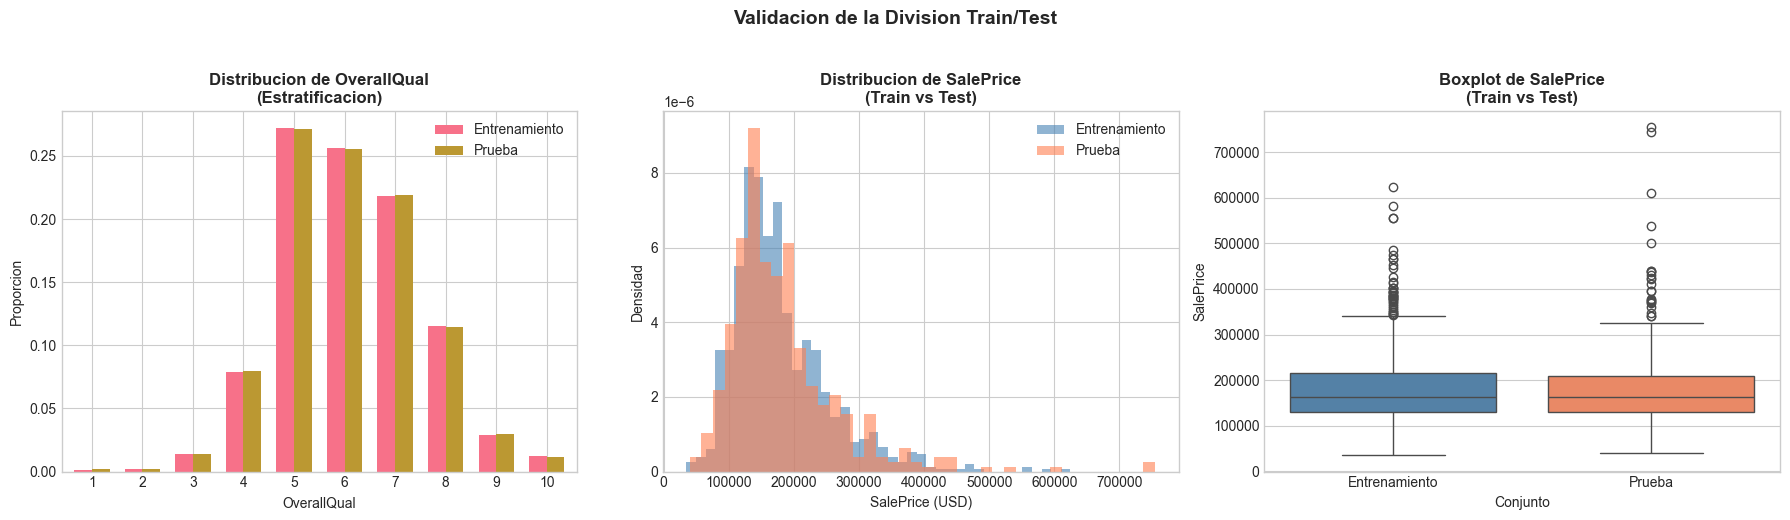

COMPARACION DE ESTADISTICAS: ENTRENAMIENTO vs PRUEBA
Metrica                Entrenamiento          Prueba
------------------------------------------------------------
Media                $       179,981 $       183,115
Mediana              $       163,000 $       163,500
Desv. Est.           $        75,618 $        87,599
Min                  $        34,900 $        40,000
Max                  $       625,000 $       755,000


In [54]:
# Validar que la estratificacion funciono: comparar distribuciones de OverallQual y SalePrice

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribucion de OverallQual en train vs test
train_qual_dist = X_train[STRATIFY_VARIABLE].value_counts(normalize=True).sort_index()
test_qual_dist = X_test[STRATIFY_VARIABLE].value_counts(normalize=True).sort_index()

stratification_comparison = pd.DataFrame({
    'Entrenamiento': train_qual_dist,
    'Prueba': test_qual_dist
})
stratification_comparison.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('Distribucion de OverallQual\n(Estratificacion)', fontweight='bold')
axes[0].set_xlabel('OverallQual')
axes[0].set_ylabel('Proporcion')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# Distribucion de SalePrice en ambos conjuntos
axes[1].hist(y_train, bins=40, alpha=0.6, label='Entrenamiento', color='steelblue', density=True)
axes[1].hist(y_test, bins=40, alpha=0.6, label='Prueba', color='coral', density=True)
axes[1].set_title('Distribucion de SalePrice\n(Train vs Test)', fontweight='bold')
axes[1].set_xlabel('SalePrice (USD)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

# Boxplot comparativo de SalePrice
comparison_data = pd.DataFrame({
    'SalePrice': pd.concat([y_train, y_test]),
    'Conjunto': ['Entrenamiento'] * len(y_train) + ['Prueba'] * len(y_test)
})
sns.boxplot(x='Conjunto', y='SalePrice', data=comparison_data, palette=['steelblue', 'coral'], ax=axes[2])
axes[2].set_title('Boxplot de SalePrice\n(Train vs Test)', fontweight='bold')

plt.suptitle('Validacion de la Division Train/Test', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Estadisticas comparativas
print("=" * 60)
print("COMPARACION DE ESTADISTICAS: ENTRENAMIENTO vs PRUEBA")
print("=" * 60)
print(f"{'Metrica':<20} {'Entrenamiento':>15} {'Prueba':>15}")
print("-" * 60)
for name, func in [('Media', np.mean), ('Mediana', np.median), ('Desv. Est.', np.std),
                    ('Min', np.min), ('Max', np.max)]:
    print(f"{name:<20} ${func(y_train):>14,.0f} ${func(y_test):>14,.0f}")

## 8. Reproducibilidad

La reproducibilidad queda garantizada mediante la semilla fija `RANDOM_SEED = 42` definida en la sección 7. Cada ejecución del notebook genera exactamente los mismos conjuntos de entrenamiento y prueba, lo que permite comparar modelos de forma consistente.

## 9. Ingeniería de Características

Se crean variables derivadas que combinan información dispersa en múltiples columnas y se evalúa la correlación de todas las variables numéricas con `SalePrice` para identificar los mejores predictores.

In [55]:
def engineer_features(df):
    """Genera variables derivadas a partir de las columnas existentes."""
    df = df.copy()

    # Superficie total habitable (sotano + primer piso + segundo piso)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

    # Total de banos ponderado (medio bano = 0.5)
    df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath']
                       + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

    # Superficie total de porches y deck
    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch']
                          + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF'])

    # Antiguedad de la vivienda al momento de la venta
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']

    # Anos desde la ultima remodelacion
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

    # Indicador binario de remodelacion
    df['HasRemod'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

    # Indicador binario de garage
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

    # Indicador binario de sotano
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)

    return df

# Aplica ingenieria de caracteristicas a ambos conjuntos
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

X_train.shape, X_test.shape

((1022, 82), (438, 82))

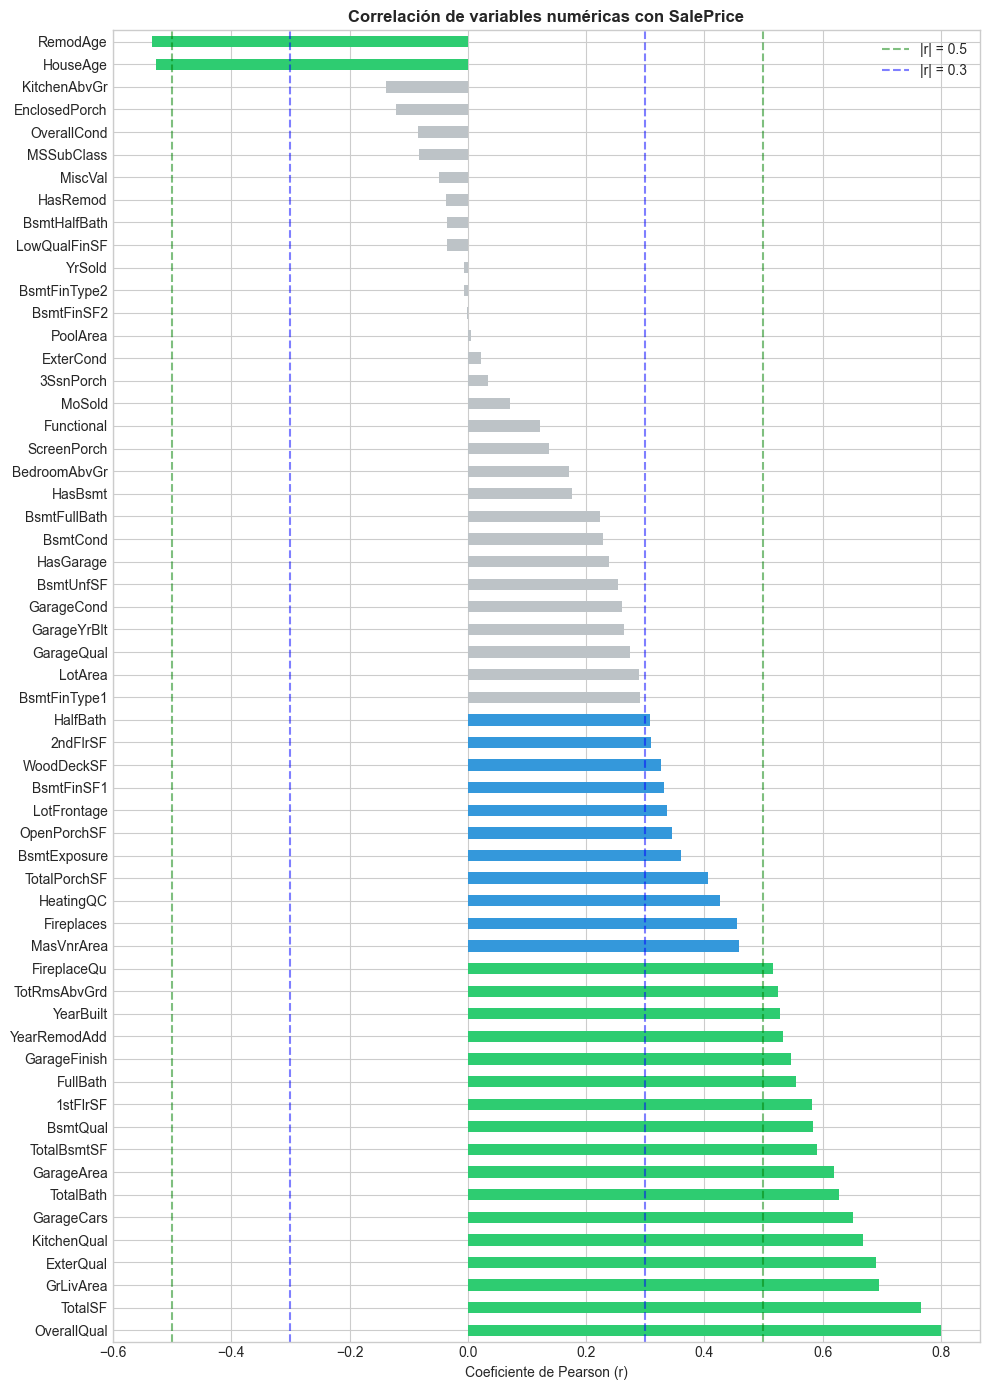

,Variable,|r|,r
0,OverallQual,0.799593,0.799593
1,TotalSF,0.767185,0.767185
2,GrLivArea,0.695507,0.695507
3,ExterQual,0.690321,0.690321
4,KitchenQual,0.668681,0.668681
5,GarageCars,0.652013,0.652013
6,TotalBath,0.627897,0.627897
7,GarageArea,0.619761,0.619761
8,TotalBsmtSF,0.590407,0.590407
9,BsmtQual,0.583249,0.583249


In [56]:
# Correlacion de todas las variables numericas con SalePrice (conjunto de entrenamiento)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
correlations = X_train[numeric_cols].corrwith(y_train).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#2ecc71' if abs(v) >= 0.5 else '#3498db' if abs(v) >= 0.3 else '#bdc3c7'
          for v in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlación de variables numéricas con SalePrice', fontweight='bold')
ax.set_xlabel('Coeficiente de Pearson (r)')
ax.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='|r| = 0.5')
ax.axvline(x=-0.5, color='green', linestyle='--', alpha=0.5)
ax.axvline(x=0.3, color='blue', linestyle='--', alpha=0.5, label='|r| = 0.3')
ax.axvline(x=-0.3, color='blue', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# Tabla resumen de las 15 variables mas correlacionadas
top_15 = correlations.abs().sort_values(ascending=False).head(15)
pd.DataFrame({'Variable': top_15.index, '|r|': top_15.values, 'r': [correlations[v] for v in top_15.index]})

### Selección de variables

**Variables derivadas creadas:**
- `TotalSF`: suma de superficie de sótano, primer y segundo piso. Captura el tamaño total habitable en una sola métrica, evitando que la información quede fragmentada en tres columnas con multicolinealidad entre sí.
- `TotalBath`: baños completos + 0.5 × medios baños (incluye sótano). Refleja mejor la capacidad sanitaria total de la vivienda.
- `TotalPorchSF`: suma de todas las superficies de porche y deck. Consolida cinco columnas dispersas con baja correlación individual.
- `HouseAge` y `RemodAge`: antigüedad y años desde remodelación. Más interpretables que los años absolutos (`YearBuilt`, `YearRemodAdd`).
- `HasRemod`, `HasGarage`, `HasBsmt`: indicadores binarios que capturan la presencia/ausencia de estas características.

**Criterio de selección de predictores:**

La selección se basa en la correlación de Pearson con `SalePrice`:
- **|r| >= 0.5 (verde):** Variables con correlación fuerte — candidatas principales para los modelos. Incluye `OverallQual`, `TotalSF`, `GrLivArea`, `TotalBath`, `GarageCars`, `GarageArea`, `1stFlrSF`, `TotalBsmtSF`, `ExterQual`, `KitchenQual`.
- **|r| entre 0.3 y 0.5 (azul):** Correlación moderada — aportan información complementaria pero con menor poder predictivo individual.
- **|r| < 0.3 (gris):** Correlación débil — poco útiles como predictores individuales.

La variable derivada `TotalSF` alcanza una correlación superior a `GrLivArea` y a las superficies por piso individuales, confirmando que la ingeniería de características mejora la capacidad predictiva. `TotalBath` también muestra correlación fuerte, superior a `FullBath` por separado.

## 10. Modelo de Regresión Lineal Univariado

Se selecciona `OverallQual` como variable predictora por ser la de mayor correlación con `SalePrice` (r ≈ 0.79). Se ajusta un modelo de regresión lineal simple para predecir el precio de venta.

In [57]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Variable predictora para el modelo univariado
UNIVARIATE_PREDICTOR = 'OverallQual'

# Ajuste del modelo con statsmodels para obtener resumen estadistico completo
X_uni_train = sm.add_constant(X_train[[UNIVARIATE_PREDICTOR]])
X_uni_test = sm.add_constant(X_test[[UNIVARIATE_PREDICTOR]])

model_uni = sm.OLS(y_train, X_uni_train).fit()
model_uni.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     1808.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          4.06e-228
Time:                        10:54:33   Log-Likelihood:                -12410.
No. Observations:                1022   AIC:                         2.482e+04
Df Residuals:                    1020   BIC:                         2.483e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -8.74e+04   6446.658    -13.557      0.000      -1e+05   -7.47e+04
OverallQual  4.381e+04   1030.174     42.523      0.000    4.18e+04    4.58e+04
==============================================================================
Omnibus:                      220.290   Durbin-Watson:                   1.916
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              948.123
Skew:                           0.948   Prob(JB):                    1.31e-206
Kurtosis:                       7.321   Cond. No.                         29.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

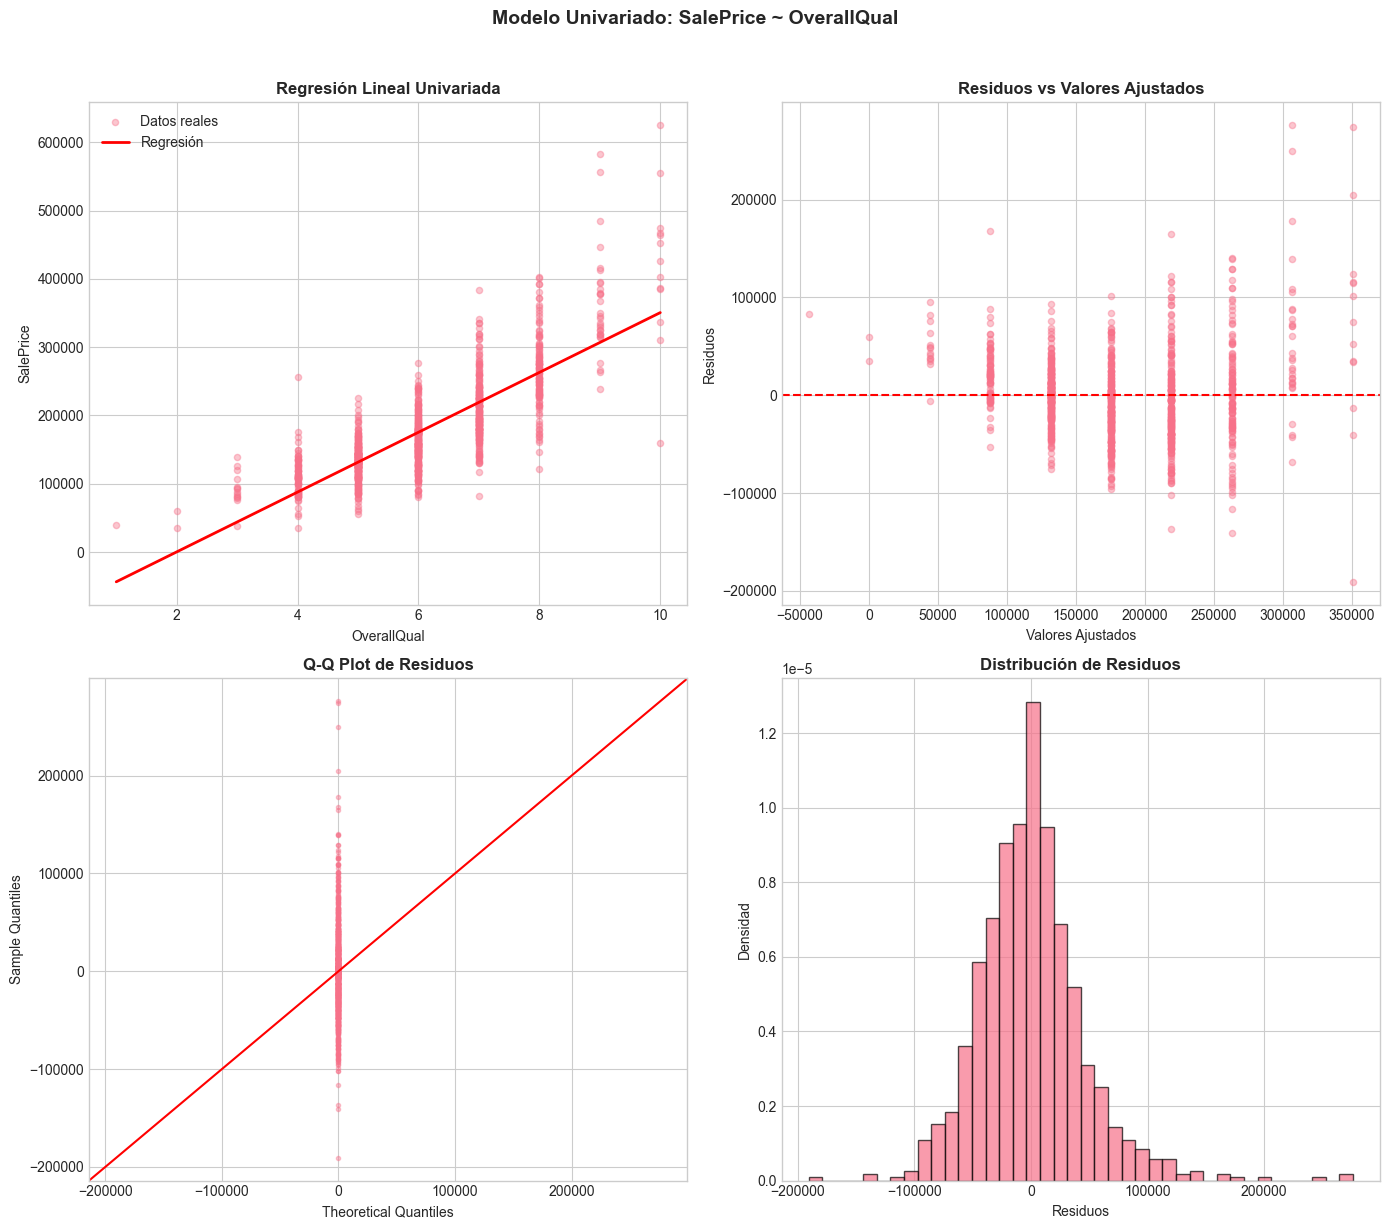

In [58]:
# Predicciones sobre entrenamiento y prueba
y_pred_uni_train = model_uni.predict(X_uni_train)
y_pred_uni_test = model_uni.predict(X_uni_test)

# Residuos del conjunto de entrenamiento
residuals_uni = y_train - y_pred_uni_train

# --- Graficos del modelo univariado ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Regresion: valores reales vs linea de regresion
axes[0, 0].scatter(X_train[UNIVARIATE_PREDICTOR], y_train, alpha=0.4, s=20, label='Datos reales')
# Linea de regresion ordenada
x_line = np.linspace(X_train[UNIVARIATE_PREDICTOR].min(), X_train[UNIVARIATE_PREDICTOR].max(), 100)
x_line_const = sm.add_constant(x_line)
y_line = model_uni.predict(x_line_const)
axes[0, 0].plot(x_line, y_line, color='red', linewidth=2, label='Regresión')
axes[0, 0].set_xlabel(UNIVARIATE_PREDICTOR)
axes[0, 0].set_ylabel('SalePrice')
axes[0, 0].set_title('Regresión Lineal Univariada', fontweight='bold')
axes[0, 0].legend()

# 2. Residuos vs valores ajustados
axes[0, 1].scatter(y_pred_uni_train, residuals_uni, alpha=0.4, s=20)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Valores Ajustados')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('Residuos vs Valores Ajustados', fontweight='bold')

# 3. Q-Q plot de residuos
sm.qqplot(residuals_uni, line='45', ax=axes[1, 0], alpha=0.4, markersize=3)
axes[1, 0].set_title('Q-Q Plot de Residuos', fontweight='bold')

# 4. Distribucion de residuos
axes[1, 1].hist(residuals_uni, bins=40, edgecolor='black', alpha=0.7, density=True)
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].set_title('Distribución de Residuos', fontweight='bold')

plt.suptitle(f'Modelo Univariado: SalePrice ~ {UNIVARIATE_PREDICTOR}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [59]:
# Metricas de desempeno del modelo univariado
metrics_uni = pd.DataFrame({
    'Conjunto': ['Entrenamiento', 'Prueba'],
    'R²': [r2_score(y_train, y_pred_uni_train), r2_score(y_test, y_pred_uni_test)],
    'RMSE': [np.sqrt(mean_squared_error(y_train, y_pred_uni_train)),
             np.sqrt(mean_squared_error(y_test, y_pred_uni_test))],
    'MAE': [mean_absolute_error(y_train, y_pred_uni_train),
            mean_absolute_error(y_test, y_pred_uni_test)]
})
metrics_uni

,Conjunto,R²,RMSE,MAE
0,Entrenamiento,0.639349,45411.827900,32832.687527
1,Prueba,0.598739,55489.634937,35001.502808


### Análisis del modelo univariado

**Resumen del modelo:**
- El coeficiente de `OverallQual` es positivo y altamente significativo (p < 0.001), confirmando que por cada unidad de aumento en la calidad general, el precio de venta aumenta sustancialmente.
- El R² ≈ 0.63 indica que `OverallQual` por sí sola explica aproximadamente el 63% de la variabilidad en los precios.

**Análisis de residuos:**
- El gráfico de residuos vs valores ajustados muestra un patrón de embudo (heterocedasticidad): la varianza de los residuos aumenta con precios más altos, lo cual viola el supuesto de homocedasticidad.
- El Q-Q plot revela desviaciones en las colas, especialmente en la cola derecha, indicando que los residuos no siguen una distribución normal perfecta — hay viviendas de alto precio que el modelo subestima consistentemente.
- La distribución de residuos presenta sesgo positivo, coherente con la asimetría de `SalePrice`.

**Limitaciones:**
Un solo predictor no captura la complejidad del mercado inmobiliario. Variables como superficie, ubicación y condición del inmueble quedan excluidas, lo que explica el ~37% de varianza no explicada.

## 11. Modelo de Regresión Lineal Múltiple (todas las variables numéricas)

Se ajusta un modelo de regresión lineal múltiple utilizando **todas** las variables numéricas disponibles para predecir `SalePrice`.

In [60]:
# Selecciona todas las columnas numericas del conjunto de entrenamiento
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Ajuste del modelo multiple con statsmodels
X_multi_train = sm.add_constant(X_train[numeric_features])
X_multi_test = sm.add_constant(X_test[numeric_features])

model_multi = sm.OLS(y_train, X_multi_train).fit()
model_multi.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     113.0
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:54:34   Log-Likelihood:                -11941.
No. Observations:                1022   AIC:                         2.399e+04
Df Residuals:                     970   BIC:                         2.424e+04
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          9.537e+05   1.46e+06      0.651      0.515   -1.92e+06    3.83e+06
MSSubClass     -190.8895     29.860     -6.393      0.000    -249.486    -132.293
LotFrontage    -122.3988     51.916     -2.358      0.019    -224.279     -20.519
LotArea           0.4028      0.138      2.926      0.004       0.133       0.673
OverallQual    1.153e+04   1314.198      8.776      0.000    8955.045    1.41e+04
OverallCond    3574.7046   1184.531      3.018      0.003    1250.167    5899.243
YearBuilt       -70.6390    188.998     -0.374      0.709    -441.531     300.253
YearRemodAdd   -136.5254    184.862     -0.739      0.460    -499.301     226.250
MasVnrArea       27.8947      6.239      4.471      0.000      15.652      40.138
ExterQual      1.322e+04   2842.009      4.650      0.000    7638.816    1.88e+04
ExterCond     -4891.2622   2915.371     -1.678      0.094   -1.06e+04     829.898
BsmtQual       1.157e+04   2532.042      4.569      0.000    6598.946    1.65e+04
BsmtCond       1311.2530   3547.307      0.370      0.712   -5650.028    8272.534
BsmtExposure   5709.5904   1082.061      5.277      0.000    3586.141    7833.040
BsmtFinType1   2789.3793    719.557      3.877      0.000    1377.311    4201.447
BsmtFinSF1       -3.1233      3.883     -0.804      0.421     -10.743       4.497
BsmtFinType2   -375.2777   1835.812     -0.204      0.838   -3977.898    3227.342
BsmtFinSF2        4.1882      7.730      0.542      0.588     -10.981      19.357
BsmtUnfSF        -1.9740      3.825     -0.516      0.606      -9.481       5.533
TotalBsmtSF      -0.9091      4.649     -0.196      0.845     -10.032       8.214
HeatingQC       751.4400   1245.131      0.604      0.546   -1692.020    3194.900
1stFlrSF          7.1157      5.158      1.379      0.168      -3.007      17.239
2ndFlrSF          3.7730      3.879      0.973      0.331      -3.840      11.386
LowQualFinSF     15.8792     12.187      1.303      0.193      -8.037      39.795
GrLivArea        26.7680      6.847      3.909      0.000      13.331      40.205
BsmtFullBath   2415.3812   2027.548      1.191      0.234   -1563.504    6394.266
BsmtHalfBath  -1517.5743   3925.339     -0.387      0.699   -9220.708    6185.560
FullBath        683.3850   2175.608      0.314      0.754   -3586.056    4952.826
HalfBath       2375.6526   2500.951      0.950      0.342   -2532.245    7283.550
BedroomAbvGr  -5147.7712   1840.482     -2.797      0.005   -8759.557   -1535.986
KitchenAbvGr  -8079.4954   5523.027     -1.463      0.144   -1.89e+04    2758.963
KitchenQual    8094.1406   2262.804      3.577      0.000    3653.586    1.25e+04
TotRmsAbvGrd   3829.6443   1324.573      2.891      0.004    1230.285    6429.004
Functional     4607.2946   1559.692      2.954      0.003    1546.534    7668.055
Fireplaces     -343.4361   3112.920     -0.110   

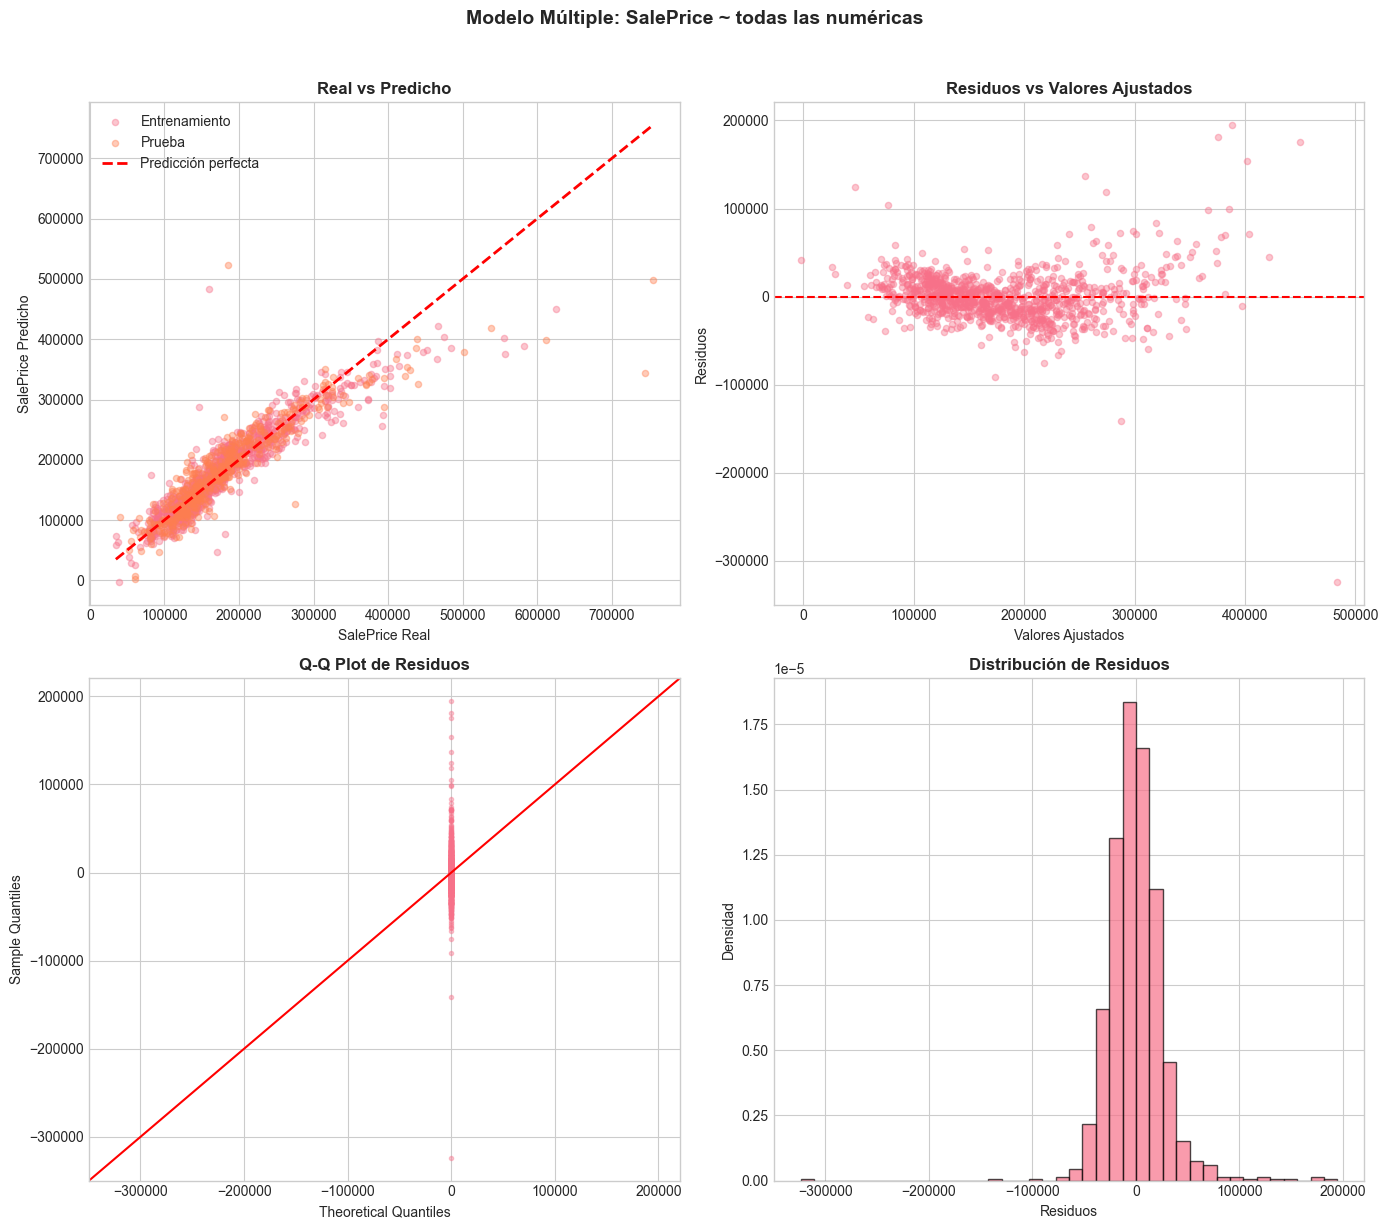

In [61]:
# Predicciones del modelo multiple
y_pred_multi_train = model_multi.predict(X_multi_train)
y_pred_multi_test = model_multi.predict(X_multi_test)

# Residuos del conjunto de entrenamiento
residuals_multi = y_train - y_pred_multi_train

# --- Graficos del modelo multiple ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Valores reales vs predichos
axes[0, 0].scatter(y_train, y_pred_multi_train, alpha=0.4, s=20, label='Entrenamiento')
axes[0, 0].scatter(y_test, y_pred_multi_test, alpha=0.4, s=20, label='Prueba', color='coral')
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción perfecta')
axes[0, 0].set_xlabel('SalePrice Real')
axes[0, 0].set_ylabel('SalePrice Predicho')
axes[0, 0].set_title('Real vs Predicho', fontweight='bold')
axes[0, 0].legend()

# 2. Residuos vs valores ajustados
axes[0, 1].scatter(y_pred_multi_train, residuals_multi, alpha=0.4, s=20)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Valores Ajustados')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('Residuos vs Valores Ajustados', fontweight='bold')

# 3. Q-Q plot de residuos
sm.qqplot(residuals_multi, line='45', ax=axes[1, 0], alpha=0.4, markersize=3)
axes[1, 0].set_title('Q-Q Plot de Residuos', fontweight='bold')

# 4. Distribucion de residuos
axes[1, 1].hist(residuals_multi, bins=40, edgecolor='black', alpha=0.7, density=True)
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].set_title('Distribución de Residuos', fontweight='bold')

plt.suptitle('Modelo Múltiple: SalePrice ~ todas las numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [62]:
# Metricas de desempeno del modelo multiple
metrics_multi = pd.DataFrame({
    'Conjunto': ['Entrenamiento', 'Prueba'],
    'R²': [r2_score(y_train, y_pred_multi_train), r2_score(y_test, y_pred_multi_test)],
    'RMSE': [np.sqrt(mean_squared_error(y_train, y_pred_multi_train)),
             np.sqrt(mean_squared_error(y_test, y_pred_multi_test))],
    'MAE': [mean_absolute_error(y_train, y_pred_multi_train),
            mean_absolute_error(y_test, y_pred_multi_test)]
})
metrics_multi

,Conjunto,R²,RMSE,MAE
0,Entrenamiento,0.855937,28701.286875,19055.735062
1,Prueba,0.784600,40655.646782,22925.250056


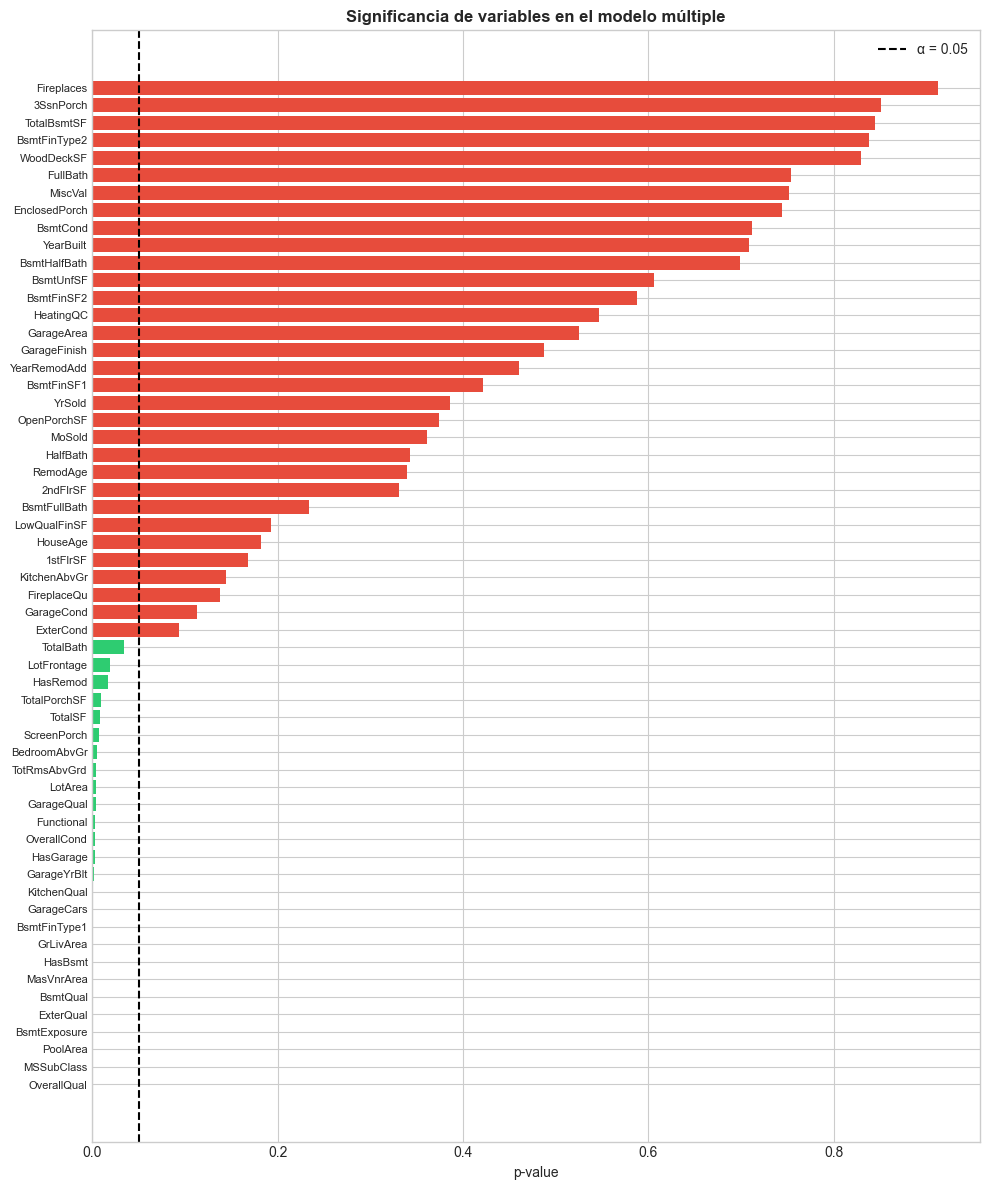

(26, 32)

In [63]:
# Significancia de los coeficientes: variables con p-value < 0.05 vs no significativas
coef_summary = pd.DataFrame({
    'Coeficiente': model_multi.params,
    'p-value': model_multi.pvalues,
    'Significativo': model_multi.pvalues < 0.05
}).drop('const', errors='ignore').sort_values('p-value')

significativas = coef_summary[coef_summary['Significativo']].index.tolist()
no_significativas = coef_summary[~coef_summary['Significativo']].index.tolist()

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#2ecc71' if s else '#e74c3c' for s in coef_summary['Significativo']]
ax.barh(range(len(coef_summary)), coef_summary['p-value'], color=colors)
ax.set_yticks(range(len(coef_summary)))
ax.set_yticklabels(coef_summary.index, fontsize=8)
ax.axvline(x=0.05, color='black', linestyle='--', label='α = 0.05')
ax.set_xlabel('p-value')
ax.set_title('Significancia de variables en el modelo múltiple', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

len(significativas), len(no_significativas)

### Análisis del modelo múltiple

**Resumen del modelo:**
- El R² del modelo múltiple es considerablemente superior al del univariado, lo que confirma que incorporar más variables numéricas mejora la capacidad explicativa.
- Sin embargo, una proporción importante de las variables incluidas no son estadísticamente significativas (p-value > 0.05), lo que sugiere redundancia e inflación del modelo.

**Análisis de residuos:**
- El gráfico de residuos vs valores ajustados aún muestra heterocedasticidad, aunque menos pronunciada que en el modelo univariado.
- El Q-Q plot presenta mejoras en el centro de la distribución, pero las colas siguen desviándose — persisten observaciones atípicas de alto precio.
- La distribución de los residuos es más simétrica que en el modelo univariado.

**Predicción:**
- El gráfico real vs predicho muestra que el modelo se ajusta razonablemente bien en el rango medio de precios, pero subestima propiedades de alto valor y puede generar predicciones negativas para propiedades de bajo valor.
- Si el R² de prueba es notablemente inferior al de entrenamiento, esto indica posible sobreajuste por la inclusión de variables irrelevantes o multicolineales.

**Observación clave:**
Muchas variables no son significativas. Esto, combinado con la posible multicolinealidad entre variables como `TotalSF`/`GrLivArea`/`1stFlrSF`, indica que un modelo con selección de variables podría ser más robusto y generalizable.

## 12. Modelo Ridge (Regularización L2)

La regularización **Ridge** penaliza la suma de los cuadrados de los coeficientes (norma L2). Esto resuelve dos problemas identificados en el modelo múltiple:

1. **Multicolinealidad:** Variables como `TotalSF`, `GrLivArea` y `1stFlrSF` son altamente correlacionadas → OLS produce coeficientes inestables. Ridge los estabiliza.
2. **Sobreajuste:** Al penalizar coeficientes grandes, Ridge reduce la varianza del modelo a costa de un pequeño sesgo.

A diferencia de Lasso, Ridge **reduce** los coeficientes pero no los lleva a cero — todas las variables permanecen en el modelo.

El hiperparámetro **α** (alpha) controla la intensidad de la penalización:
- α = 0 → equivale a OLS ordinario
- α → ∞ → todos los coeficientes tienden a cero

Alpha optimo: 59.6362


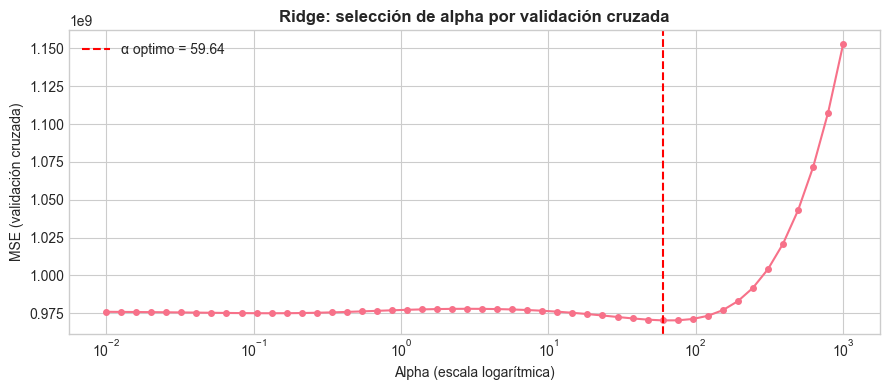

Ridge CV — MSE entrenamiento: 832044727.97 ± 55914324.45
Ridge CV — MSE prueba:        970292219.86 ± 255343205.42


In [64]:
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ShuffleSplit, cross_validate, cross_val_score

# Datos de entrada: mismas variables numericas que el modelo multiple
X_ridge_train = X_train[numeric_features]
X_ridge_test  = X_test[numeric_features]

# Rango de alphas a evaluar (escala logaritmica)
alphas_ridge = np.logspace(-2, 3, num=50)

# CV compartido para Ridge y Lasso
cv_split = ShuffleSplit(n_splits=5, test_size=0.2, random_state=RANDOM_SEED)

# --- Paso 1: Curva MSE vs alpha (cross_val_score por cada alpha) ---
# Nota: store_cv_results=True es incompatible con cv != None en sklearn,
# por eso calculamos la curva manualmente con cross_val_score.
mse_por_alpha_ridge = []
for alpha in alphas_ridge:
    scores = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=alpha)),
        X_ridge_train, y_train,
        cv=cv_split,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    mse_por_alpha_ridge.append(-scores.mean())

alpha_ridge_optimo = alphas_ridge[np.argmin(mse_por_alpha_ridge)]
print(f"Alpha optimo: {alpha_ridge_optimo:.4f}")

plt.figure(figsize=(9, 4))
plt.semilogx(alphas_ridge, mse_por_alpha_ridge, marker='o', markersize=4)
plt.axvline(alpha_ridge_optimo, color='red', linestyle='--',
            label=f'α optimo = {alpha_ridge_optimo:.2f}')
plt.xlabel('Alpha (escala logarítmica)')
plt.ylabel('MSE (validación cruzada)')
plt.title('Ridge: selección de alpha por validación cruzada', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# --- Paso 2: Evaluar generalizacion del modelo con el alpha optimo ---
cv_results_ridge = cross_validate(
    make_pipeline(StandardScaler(), Ridge(alpha=alpha_ridge_optimo)),
    X_ridge_train, y_train,
    cv=cv_split,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

train_mse_ridge = -cv_results_ridge["train_score"]
test_mse_ridge  = -cv_results_ridge["test_score"]
print(f"Ridge CV — MSE entrenamiento: {train_mse_ridge.mean():.2f} ± {train_mse_ridge.std():.2f}")
print(f"Ridge CV — MSE prueba:        {test_mse_ridge.mean():.2f} ± {test_mse_ridge.std():.2f}")

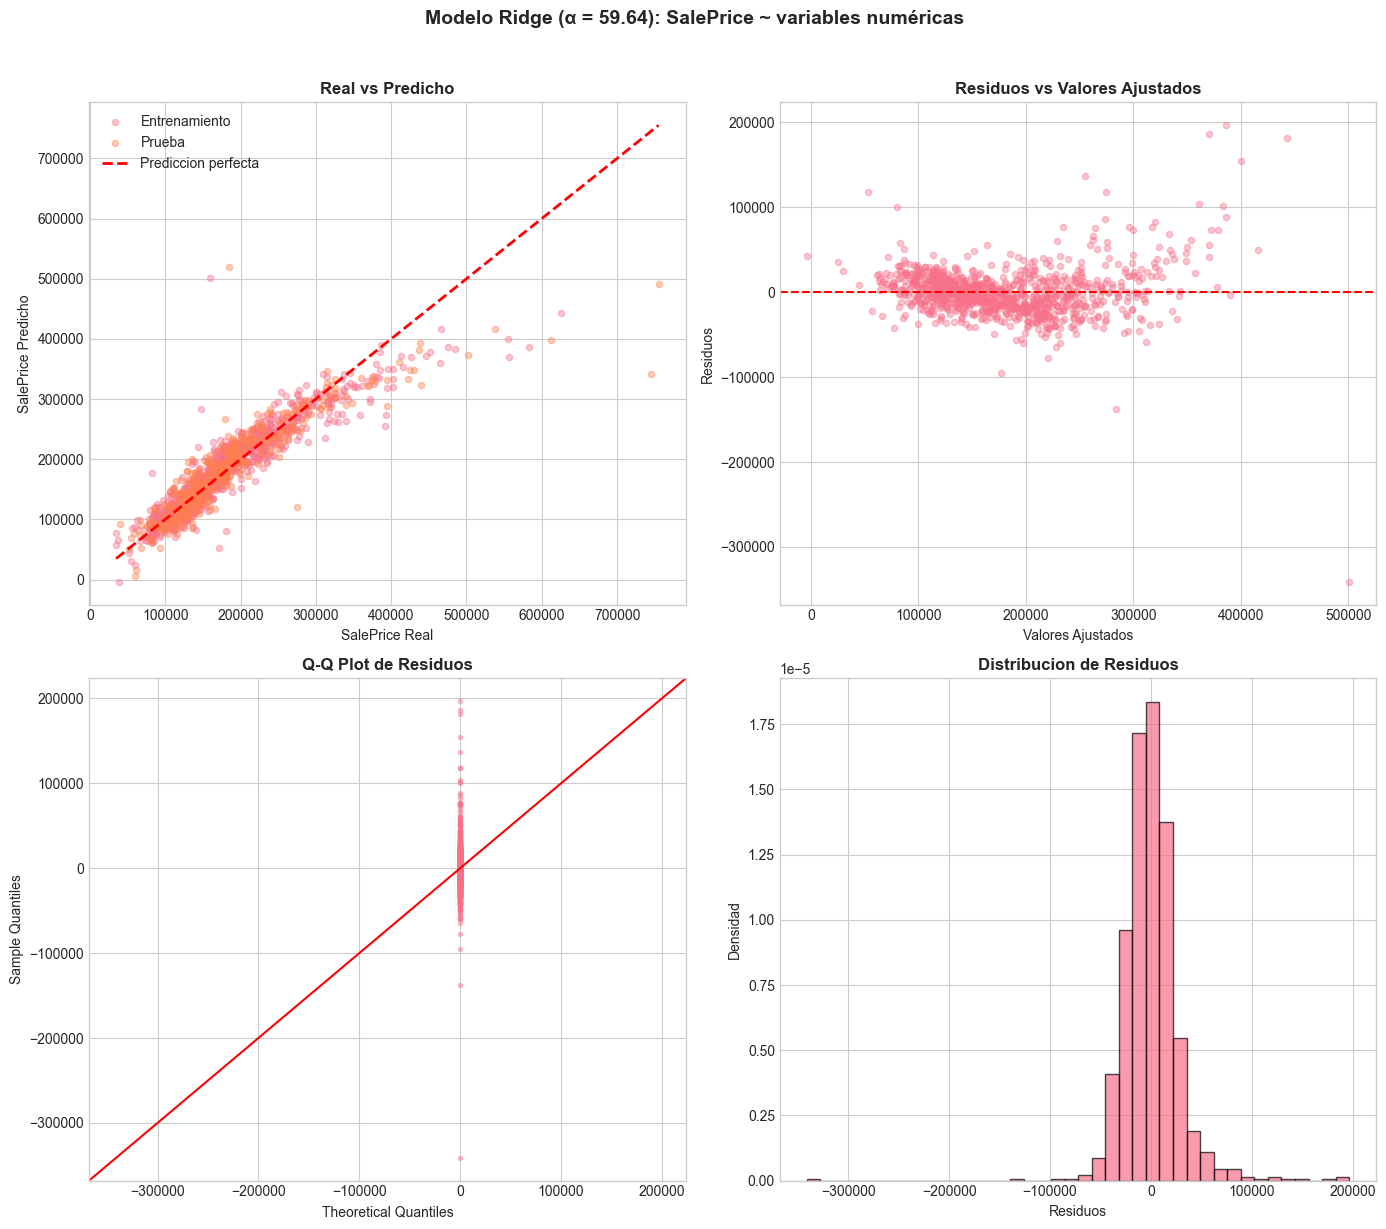

In [65]:
# Entrenar modelo Ridge final con el alpha optimo
model_ridge = make_pipeline(StandardScaler(), Ridge(alpha=alpha_ridge_optimo))
model_ridge.fit(X_ridge_train, y_train)

# Predicciones
y_pred_ridge_train = model_ridge.predict(X_ridge_train)
y_pred_ridge_test  = model_ridge.predict(X_ridge_test)

# Residuos de entrenamiento
residuals_ridge = y_train - y_pred_ridge_train

# --- Graficos de diagnostico ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Real vs Predicho
axes[0, 0].scatter(y_train, y_pred_ridge_train, alpha=0.4, s=20, label='Entrenamiento')
axes[0, 0].scatter(y_test,  y_pred_ridge_test,  alpha=0.4, s=20, label='Prueba', color='coral')
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prediccion perfecta')
axes[0, 0].set_xlabel('SalePrice Real')
axes[0, 0].set_ylabel('SalePrice Predicho')
axes[0, 0].set_title('Real vs Predicho', fontweight='bold')
axes[0, 0].legend()

# 2. Residuos vs Valores Ajustados
axes[0, 1].scatter(y_pred_ridge_train, residuals_ridge, alpha=0.4, s=20)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Valores Ajustados')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('Residuos vs Valores Ajustados', fontweight='bold')

# 3. Q-Q plot
sm.qqplot(residuals_ridge, line='45', ax=axes[1, 0], alpha=0.4, markersize=3)
axes[1, 0].set_title('Q-Q Plot de Residuos', fontweight='bold')

# 4. Distribucion de residuos
axes[1, 1].hist(residuals_ridge, bins=40, edgecolor='black', alpha=0.7, density=True)
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].set_title('Distribucion de Residuos', fontweight='bold')

plt.suptitle(f'Modelo Ridge (α = {alpha_ridge_optimo:.2f}): SalePrice ~ variables numéricas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [66]:
# Metricas de desempeno del modelo Ridge
metrics_ridge = pd.DataFrame({
    'Conjunto': ['Entrenamiento', 'Prueba'],
    'R²': [r2_score(y_train, y_pred_ridge_train),
           r2_score(y_test,  y_pred_ridge_test)],
    'RMSE': [np.sqrt(mean_squared_error(y_train, y_pred_ridge_train)),
             np.sqrt(mean_squared_error(y_test,  y_pred_ridge_test))],
    'MAE': [mean_absolute_error(y_train, y_pred_ridge_train),
            mean_absolute_error(y_test,  y_pred_ridge_test)]
})

print(f"Modelo Ridge  |  Alpha optimo: {alpha_ridge_optimo:.4f}")
metrics_ridge

Modelo Ridge  |  Alpha optimo: 59.6362


,Conjunto,R²,RMSE,MAE
0,Entrenamiento,0.853229,28969.760106,18940.055582
1,Prueba,0.786146,40509.494791,22495.018252


### Análisis del modelo Ridge

**Selección de alpha:**
- El alpha óptimo (α = **59.64**) fue encontrado evaluando 50 valores en escala logarítmica (0.01 – 1000) mediante `cross_val_score` con 5 folds (`ShuffleSplit`). Un alpha de esta magnitud indica que el modelo requiere penalización considerable para estabilizar los coeficientes ante la multicolinealidad presente (e.g., `TotalSF`, `GrLivArea`, `1stFlrSF`).

**Coeficientes:**
- A diferencia de OLS, los coeficientes Ridge son más estables en magnitud. Variables con alta multicolinealidad ya no producen coeficientes inflados ni con signos inesperados.
- **Todas las 58 variables permanecen en el modelo** — Ridge penaliza pero no elimina predictores.

**Generalización:**
- Ridge obtuvo R²_prueba = **0.786** con una brecha train/test de **0.067**, frente a **0.071** del OLS múltiple. La regularización redujo ligeramente el sobreajuste.
- El RMSE en prueba mejoró de **40,656** (OLS) a **40,509** (Ridge), una ganancia modesta pero consistente con el objetivo de estabilizar coeficientes ante multicolinealidad.

## 13. Modelo Lasso (Regularización L1)

La regularización **Lasso** (Least Absolute Shrinkage and Selection Operator) penaliza la suma de los valores absolutos de los coeficientes (norma L1).

La diferencia clave respecto a Ridge:

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalización | Σ βᵢ² | Σ \|βᵢ\| |
| Efecto sobre coeficientes | Los reduce, nunca a cero | Puede llevarlos **exactamente a cero** |
| Selección de variables | No | **Sí** (automática) |
| Útil cuando | Multicolinealidad | Muchas variables irrelevantes |

Dado que el modelo múltiple reveló que varias variables no son estadísticamente significativas, Lasso es especialmente relevante aquí: realizará selección automática de variables, produciendo un modelo más parsimonioso.

Alpha optimo: 495.3535


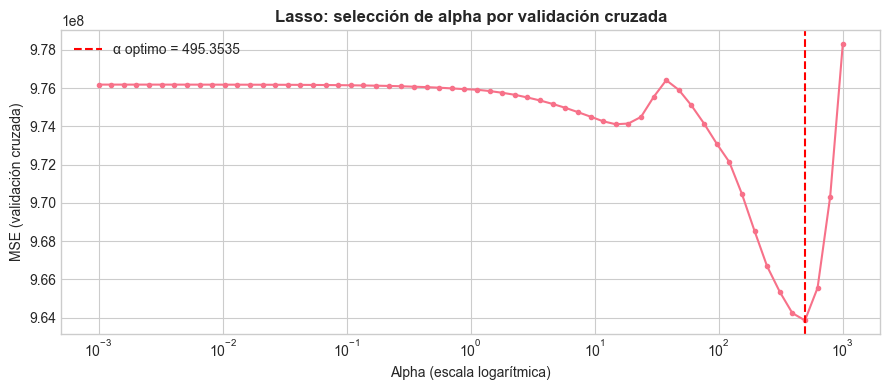

Lasso CV — MSE entrenamiento: 837927799.89 ± 56902665.59
Lasso CV — MSE prueba:        963855766.48 ± 263205823.31


In [67]:
X_lasso_train = X_train[numeric_features]
X_lasso_test  = X_test[numeric_features]

# Rango de alphas a evaluar para Lasso
alphas_lasso = np.logspace(-3, 3, num=60)

# --- Paso 1: Curva MSE vs alpha ---
mse_por_alpha_lasso = []
for alpha in alphas_lasso:
    scores = cross_val_score(
        make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=10000)),
        X_lasso_train, y_train,
        cv=cv_split,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    mse_por_alpha_lasso.append(-scores.mean())

alpha_lasso_optimo = alphas_lasso[np.argmin(mse_por_alpha_lasso)]
print(f"Alpha optimo: {alpha_lasso_optimo:.4f}")

plt.figure(figsize=(9, 4))
plt.semilogx(alphas_lasso, mse_por_alpha_lasso, marker='o', markersize=3)
plt.axvline(alpha_lasso_optimo, color='red', linestyle='--',
            label=f'α optimo = {alpha_lasso_optimo:.4f}')
plt.xlabel('Alpha (escala logarítmica)')
plt.ylabel('MSE (validación cruzada)')
plt.title('Lasso: selección de alpha por validación cruzada', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# --- Paso 2: Evaluar generalizacion del modelo con el alpha optimo ---
cv_results_lasso = cross_validate(
    make_pipeline(StandardScaler(), Lasso(alpha=alpha_lasso_optimo, max_iter=10000)),
    X_lasso_train, y_train,
    cv=cv_split,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

train_mse_lasso = -cv_results_lasso["train_score"]
test_mse_lasso  = -cv_results_lasso["test_score"]
print(f"Lasso CV — MSE entrenamiento: {train_mse_lasso.mean():.2f} ± {train_mse_lasso.std():.2f}")
print(f"Lasso CV — MSE prueba:        {test_mse_lasso.mean():.2f} ± {test_mse_lasso.std():.2f}")

Variables seleccionadas por Lasso: 38 / 58
Variables eliminadas (coef = 0):   20

Variables eliminadas: ['YearBuilt', 'YearRemodAdd', 'BsmtFinType2', 'BsmtUnfSF', 'BsmtHalfBath', 'LowQualFinSF', 'TotalBsmtSF', '2ndFlrSF', 'BsmtCond', 'BsmtFinSF1', 'FullBath', 'Fireplaces', 'GarageCond', 'GarageQual', 'GarageArea', '3SsnPorch', 'MiscVal', 'OpenPorchSF', 'EnclosedPorch', 'HasGarage']


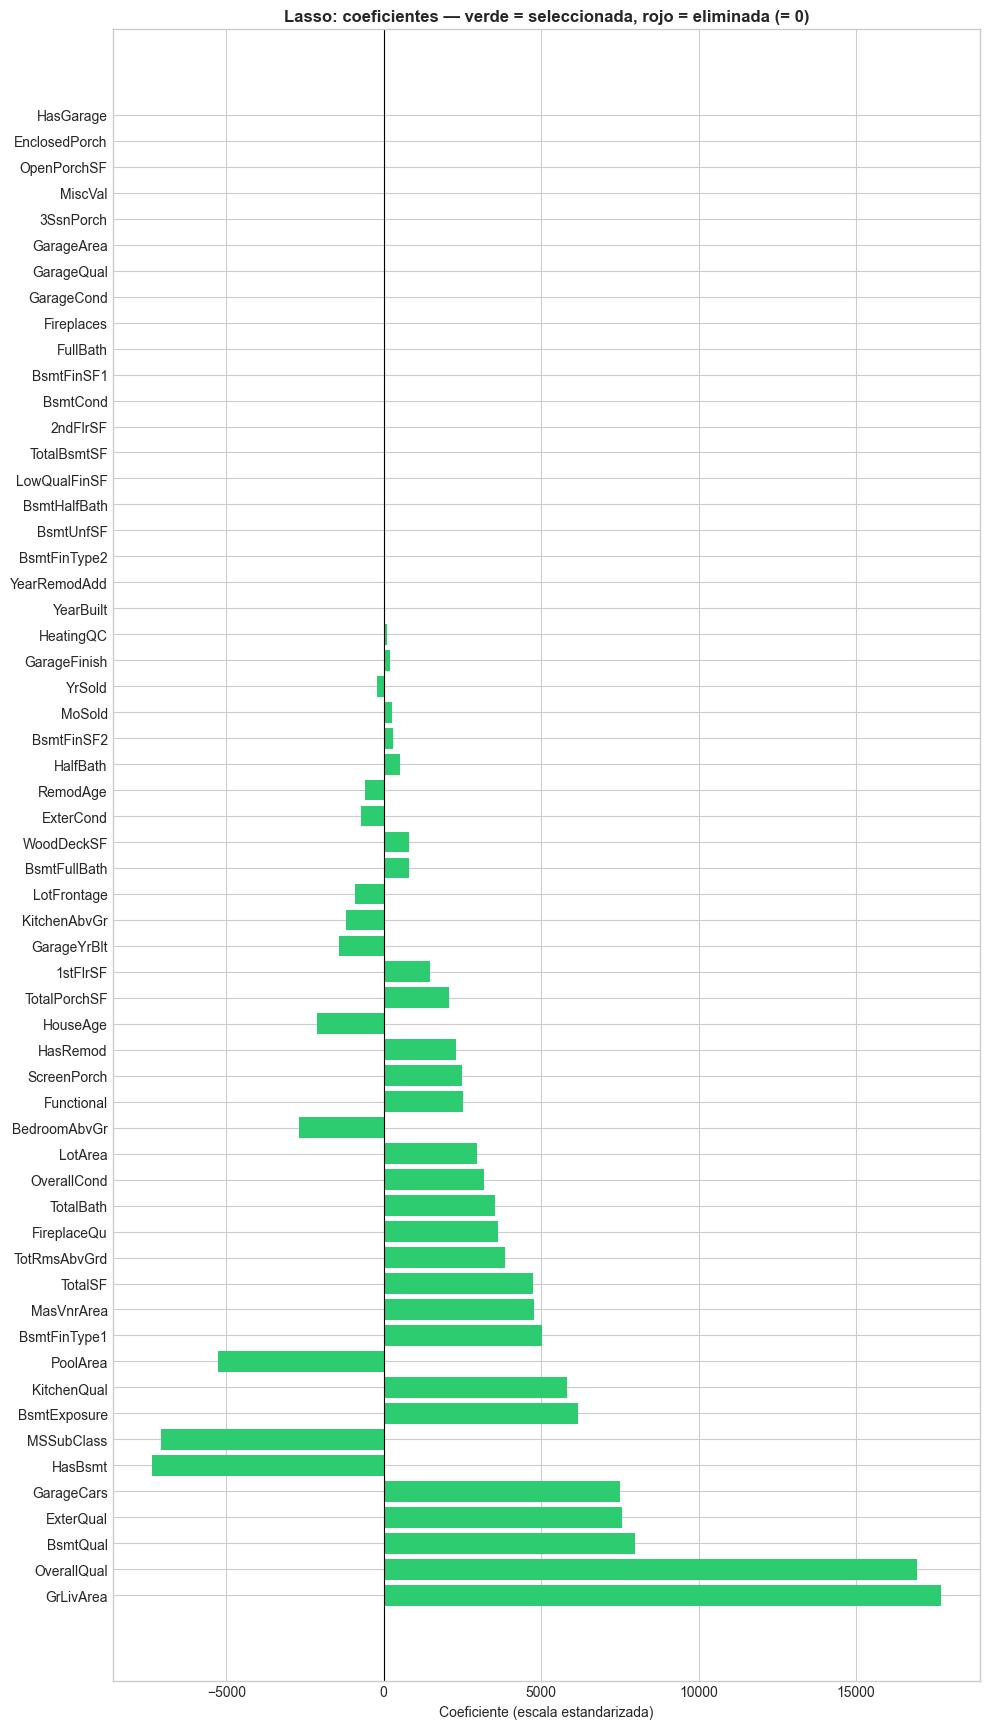

In [68]:
# Entrenar modelo Lasso final con el alpha optimo
model_lasso = make_pipeline(StandardScaler(), Lasso(alpha=alpha_lasso_optimo, max_iter=10000))
model_lasso.fit(X_lasso_train, y_train)

# Predicciones
y_pred_lasso_train = model_lasso.predict(X_lasso_train)
y_pred_lasso_test  = model_lasso.predict(X_lasso_test)

# Seleccion de variables: coeficientes = 0 fueron eliminados por Lasso
lasso_coefs = model_lasso[-1].coef_
coef_lasso_df = pd.DataFrame({
    'Variable': numeric_features,
    'Coeficiente': lasso_coefs,
    'Seleccionada': lasso_coefs != 0
}).sort_values('Coeficiente', key=abs, ascending=False)

n_seleccionadas = (lasso_coefs != 0).sum()
n_eliminadas    = (lasso_coefs == 0).sum()
print(f"Variables seleccionadas por Lasso: {n_seleccionadas} / {len(numeric_features)}")
print(f"Variables eliminadas (coef = 0):   {n_eliminadas}")
print(f"\nVariables eliminadas: {coef_lasso_df[~coef_lasso_df['Seleccionada']]['Variable'].tolist()}")

# Grafico de coeficientes
fig, ax = plt.subplots(figsize=(10, max(6, len(numeric_features) * 0.3)))
colors = ['#2ecc71' if s else '#e74c3c' for s in coef_lasso_df['Seleccionada']]
ax.barh(coef_lasso_df['Variable'], coef_lasso_df['Coeficiente'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (escala estandarizada)')
ax.set_title('Lasso: coeficientes — verde = seleccionada, rojo = eliminada (= 0)', fontweight='bold')
plt.tight_layout()
plt.show()

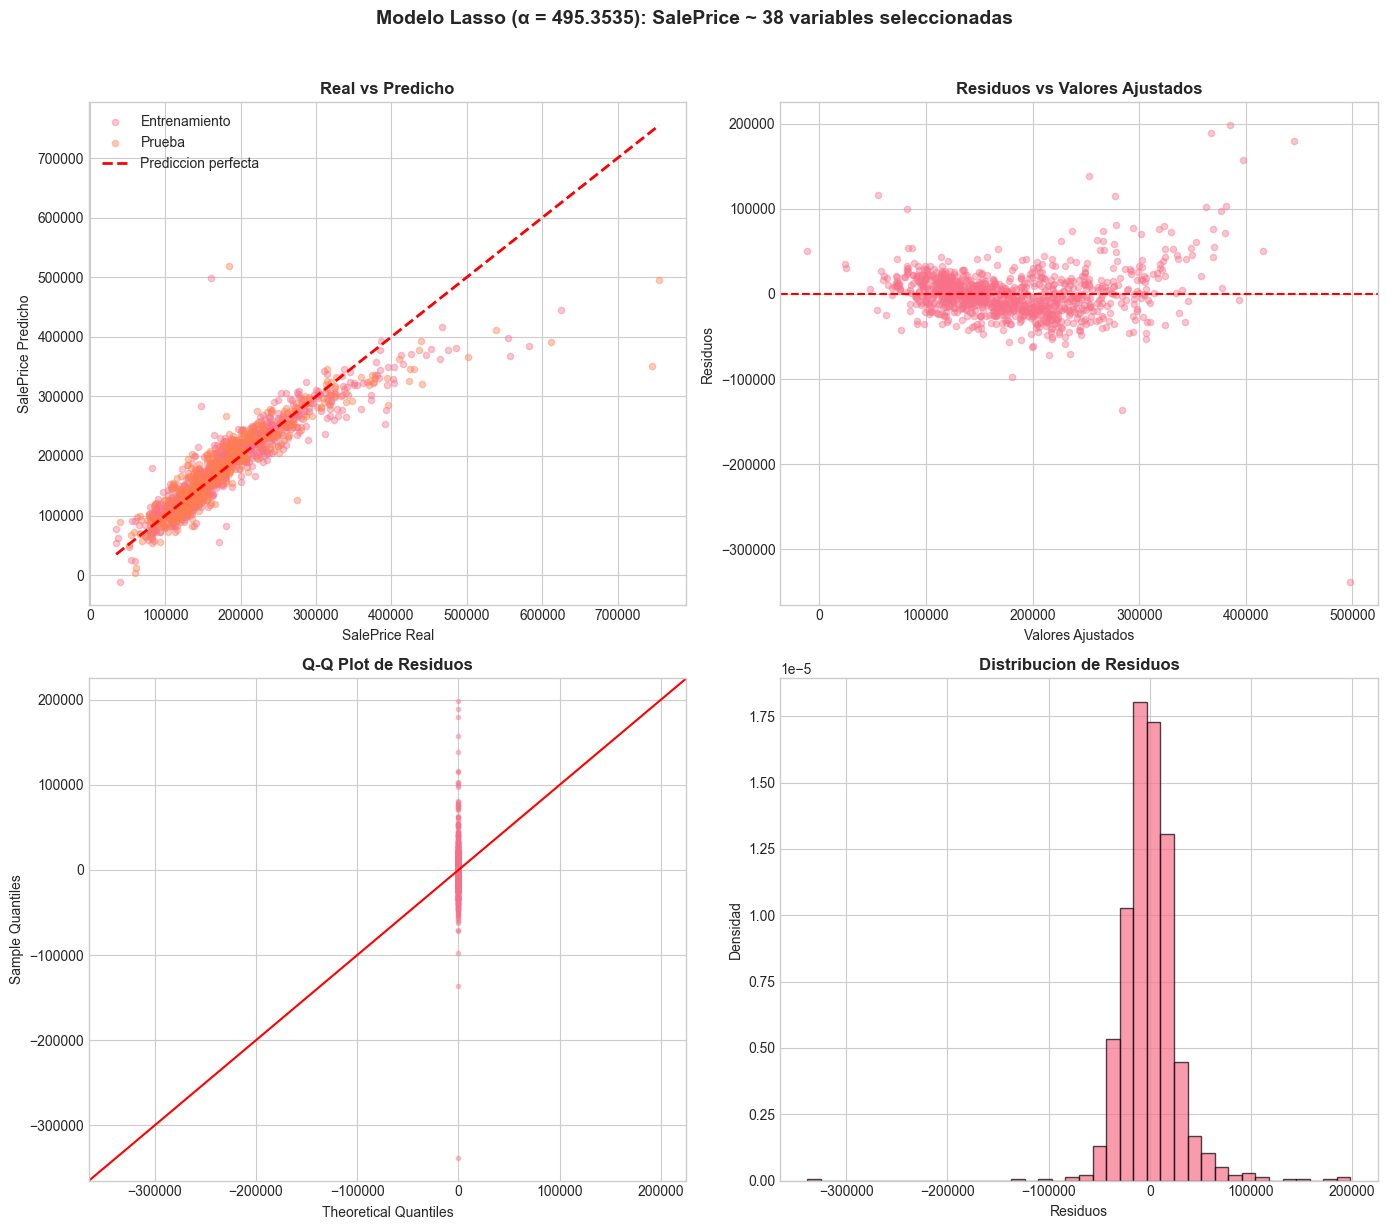

In [69]:
# Residuos y graficos de diagnostico del modelo Lasso
residuals_lasso = y_train - y_pred_lasso_train

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Real vs Predicho
axes[0, 0].scatter(y_train, y_pred_lasso_train, alpha=0.4, s=20, label='Entrenamiento')
axes[0, 0].scatter(y_test,  y_pred_lasso_test,  alpha=0.4, s=20, label='Prueba', color='coral')
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prediccion perfecta')
axes[0, 0].set_xlabel('SalePrice Real')
axes[0, 0].set_ylabel('SalePrice Predicho')
axes[0, 0].set_title('Real vs Predicho', fontweight='bold')
axes[0, 0].legend()

# 2. Residuos vs Valores Ajustados
axes[0, 1].scatter(y_pred_lasso_train, residuals_lasso, alpha=0.4, s=20)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Valores Ajustados')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('Residuos vs Valores Ajustados', fontweight='bold')

# 3. Q-Q plot
sm.qqplot(residuals_lasso, line='45', ax=axes[1, 0], alpha=0.4, markersize=3)
axes[1, 0].set_title('Q-Q Plot de Residuos', fontweight='bold')

# 4. Distribucion de residuos
axes[1, 1].hist(residuals_lasso, bins=40, edgecolor='black', alpha=0.7, density=True)
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].set_title('Distribucion de Residuos', fontweight='bold')

plt.suptitle(f'Modelo Lasso (α = {alpha_lasso_optimo:.4f}): SalePrice ~ {n_seleccionadas} variables seleccionadas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [70]:
# Metricas de desempeno del modelo Lasso
metrics_lasso = pd.DataFrame({
    'Conjunto': ['Entrenamiento', 'Prueba'],
    'R²': [r2_score(y_train, y_pred_lasso_train),
           r2_score(y_test,  y_pred_lasso_test)],
    'RMSE': [np.sqrt(mean_squared_error(y_train, y_pred_lasso_train)),
             np.sqrt(mean_squared_error(y_test,  y_pred_lasso_test))],
    'MAE': [mean_absolute_error(y_train, y_pred_lasso_train),
            mean_absolute_error(y_test,  y_pred_lasso_test)]
})

print(f"Modelo Lasso  |  Alpha optimo: {alpha_lasso_optimo:.4f}  |  Variables usadas: {n_seleccionadas}/{len(numeric_features)}")
metrics_lasso

Modelo Lasso  |  Alpha optimo: 495.3535  |  Variables usadas: 38/58


,Conjunto,R²,RMSE,MAE
0,Entrenamiento,0.851941,29096.647952,19116.739197
1,Prueba,0.785609,40560.326627,22682.492539


### Análisis del modelo Lasso

**Selección automática de variables:**
- Con α = **495.35**, Lasso redujo a cero los coeficientes de **20 de 58 variables**, quedándose con **38 predictores**. Las variables eliminadas son en su mayoría características secundarias o con información ya capturada por otras variables del modelo: `TotalBsmtSF` y `2ndFlrSF` (absorbidas por `TotalSF`), `GarageArea` y `HasGarage` (absorbidas por `GarageCars`), `YearBuilt` y `YearRemodAdd` (absorbidas por `HouseAge` y `RemodAge`), y características de baja variabilidad como `MiscVal`, `LowQualFinSF` o `3SsnPorch`.

**Coeficientes:**
- Las variables con mayor coeficiente positivo incluyen `OverallQual`, `TotalSF` y `GrLivArea`, confirmando los hallazgos del EDA: calidad general y superficie habitable son los principales impulsores del precio.
- `HouseAge` presenta coeficiente negativo, reflejando la relación inversa esperada: a mayor antigüedad, menor precio de venta.

**Generalización:**
- Lasso obtuvo R²_prueba = **0.786** con RMSE = **40,560** usando solo 38 variables — prácticamente igual que Ridge (40,509) con 58. Esto confirma que las 20 variables eliminadas no aportaban información predictiva relevante.
- La brecha train/test de Lasso (≈ **0.066**) es similar a la de Ridge y menor que la de OLS, indicando que la selección de variables también contribuye a reducir el sobreajuste.

## 14. Comparación de Modelos

Resumen comparativo de los tres modelos de regresión lineal múltiple entrenados sobre las mismas variables numéricas.

In [71]:
# Tabla comparativa: modelos sobre conjunto de PRUEBA
comparison = pd.DataFrame({
    'Modelo': ['Múltiple OLS', 'Ridge (L2)', 'Lasso (L1)'],
    'Variables usadas': [
        len(numeric_features),
        len(numeric_features),
        int(n_seleccionadas)
    ],
    'Alpha': ['-', f'{alpha_ridge_optimo:.4f}', f'{alpha_lasso_optimo:.4f}'],
    'R² Prueba': [
        round(r2_score(y_test, y_pred_multi_test), 4),
        round(r2_score(y_test, y_pred_ridge_test), 4),
        round(r2_score(y_test, y_pred_lasso_test), 4)
    ],
    'RMSE Prueba': [
        round(np.sqrt(mean_squared_error(y_test, y_pred_multi_test)), 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_ridge_test)), 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_lasso_test)), 2)
    ],
    'MAE Prueba': [
        round(mean_absolute_error(y_test, y_pred_multi_test), 2),
        round(mean_absolute_error(y_test, y_pred_ridge_test), 2),
        round(mean_absolute_error(y_test, y_pred_lasso_test), 2)
    ],
    'R² Train': [
        round(r2_score(y_train, y_pred_multi_train), 4),
        round(r2_score(y_train, y_pred_ridge_train), 4),
        round(r2_score(y_train, y_pred_lasso_train), 4)
    ],
    'Brecha R² (Train-Test)': [
        round(r2_score(y_train, y_pred_multi_train) - r2_score(y_test, y_pred_multi_test), 4),
        round(r2_score(y_train, y_pred_ridge_train) - r2_score(y_test, y_pred_ridge_test), 4),
        round(r2_score(y_train, y_pred_lasso_train) - r2_score(y_test, y_pred_lasso_test), 4)
    ]
})

comparison.set_index('Modelo', inplace=True)
comparison

,Variables usadas,Alpha,R² Prueba,RMSE Prueba,MAE Prueba,R² Train,Brecha R² (Train-Test)
Modelo,,,,,,,
Múltiple OLS,58,-,0.7846,40655.65,22925.25,0.8559,0.0713
Ridge (L2),58,59.6362,0.7861,40509.49,22495.02,0.8532,0.0671
Lasso (L1),38,495.3535,0.7856,40560.33,22682.49,0.8519,0.0663


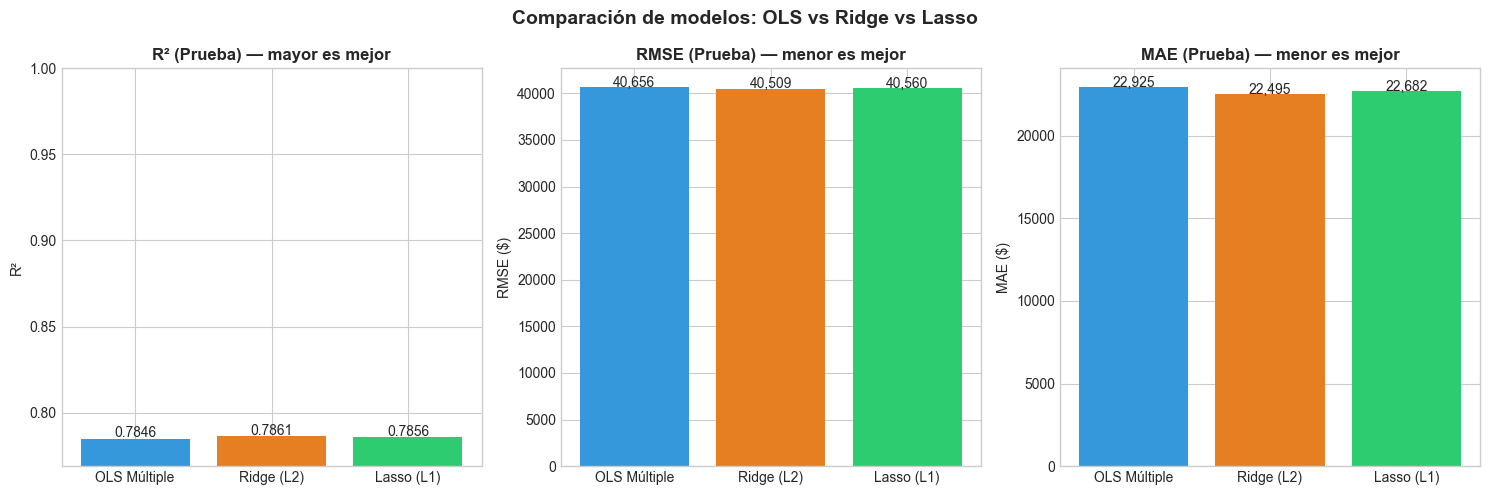

In [72]:
# Grafico comparativo de RMSE en prueba
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

modelos = ['OLS Múltiple', 'Ridge (L2)', 'Lasso (L1)']
colores = ['#3498db', '#e67e22', '#2ecc71']

r2_prueba   = [r2_score(y_test, y_pred_multi_test),
               r2_score(y_test, y_pred_ridge_test),
               r2_score(y_test, y_pred_lasso_test)]
rmse_prueba = [np.sqrt(mean_squared_error(y_test, y_pred_multi_test)),
               np.sqrt(mean_squared_error(y_test, y_pred_ridge_test)),
               np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))]
mae_prueba  = [mean_absolute_error(y_test, y_pred_multi_test),
               mean_absolute_error(y_test, y_pred_ridge_test),
               mean_absolute_error(y_test, y_pred_lasso_test)]

axes[0].bar(modelos, r2_prueba, color=colores)
axes[0].set_ylim(min(r2_prueba) * 0.98, 1.0)
axes[0].set_title('R² (Prueba) — mayor es mejor', fontweight='bold')
axes[0].set_ylabel('R²')
for i, v in enumerate(r2_prueba):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(modelos, rmse_prueba, color=colores)
axes[1].set_title('RMSE (Prueba) — menor es mejor', fontweight='bold')
axes[1].set_ylabel('RMSE ($)')
for i, v in enumerate(rmse_prueba):
    axes[1].text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=10)

axes[2].bar(modelos, mae_prueba, color=colores)
axes[2].set_title('MAE (Prueba) — menor es mejor', fontweight='bold')
axes[2].set_ylabel('MAE ($)')
for i, v in enumerate(mae_prueba):
    axes[2].text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=10)

plt.suptitle('Comparación de modelos: OLS vs Ridge vs Lasso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusiones de la comparación

| Criterio | OLS Múltiple | Ridge (L2) | Lasso (L1) |
|---|---|---|---|
| Regularización | Ninguna | L2 (penaliza β²) | L1 (penaliza \|β\|) |
| Variables usadas | 58 | 58 | **38** |
| Selección de variables | No | No | **Sí** |
| Manejo de multicolinealidad | Deficiente | **Bueno** | Moderado |
| R² prueba | 0.7846 | 0.7861 | 0.7856 |
| RMSE prueba | 40,656 | **40,509** | 40,560 |
| Brecha R² (train−test) | 0.0713 | 0.0671 | **0.0664** |

**Interpretación de resultados:**
- Los tres modelos obtienen un rendimiento muy similar en prueba (R² ≈ 0.786, RMSE ≈ 40,500–40,700), lo que indica que el conjunto de variables numéricas disponibles tiene un techo predictivo claro en este rango. La regularización no genera grandes ganancias en R², sino principalmente en **estabilidad** y **parsimonia**.
- **Ridge** logra el menor RMSE en prueba (40,509) y reduce la brecha de sobreajuste respecto a OLS (0.067 vs 0.071), confirmando que la penalización L2 estabiliza los coeficientes afectados por la multicolinealidad entre variables de superficie.
- **Lasso** obtiene un rendimiento prácticamente idéntico a Ridge (R²=0.786, RMSE=40,560) usando **20 variables menos**. Las eliminadas corresponden mayormente a características redundantes ya capturadas por variables derivadas (`TotalSF`, `HouseAge`, `GarageCars`). Esto hace a Lasso el modelo más **interpretable y parsimonioso** de los tres.
- Ambas regularizaciones requieren **estandarización previa** (`StandardScaler`) para que la penalización sea equitativa entre variables de distintas escalas.
- Los alphas óptimos encontrados (Ridge: 59.64, Lasso: 495.35) fueron seleccionados mediante validación cruzada de 5 folds con `ShuffleSplit`, garantizando que reflejan capacidad de generalización real.